# MassMIND LWIR Semantic Segmentation — Final Project Deliverable

*Authors*: Lucas Coelho, Lucas Aparicio and Lars Husemann

*Course*: Computer Vision — Assignment 2

This notebook is the final deliverable of the 2026 Computer Vision Course. It proposes a custom CV-AI model to perform semantic segmentation on the Long-Wave Infrared image data set (MassMIND) captured in and around Boston Harbour. We benchmark our model, discuss design choices and results, as well as future outlooks.

## 1. Introduction

Autonomous maritime navigation requires reliable scene understanding under
all lighting and weather conditions. RGB cameras fail at night or in fog,
but *Long-Wave* *Infrared* *(LWIR)* sensors can detect the heat emitted by
objects, producing a single channel image which is robust for these conditions.
Performing pixel-level semantic segmentation on LWIR imagery is therefore a
key capability for safe vessel operation although there are few public implementations using this appreoach

The *MassMIND* dataset is a sizeable public benchmark:
2,916 paired LWIR frames captured in and around Boston Harbour, with 
pixel-level masks across 7 maritime classes *sky, **water, **bridge*,
*obstacle, **living_obs, **background, **and* *self*.The dominant challenge
of this dataset is severe class imbalance: sky and water together account
for roughly 80% of all pixels, while critical classes such as *bridge* 
and *living_obs* are rare. This leads to some choices in this work to be 
in response to that imbalance. 

### Objectives

The assignment requires us to:

1. Propose a *custom* AI model that performs semantic segmentation from
   the LWIR image.
2. *Train and test* it *with and without* data augmentation.
3. Report *IoU* of training and testing, *Precision, **Recall*, and
   *model complexity* (parameter count).
4. Compare against *at least one existing model* we use a U-Net with a VGG-16 encoder 
   in two varients, pre-trained and from scratch.
5. Discuss the results in the context of the MassMIND paper. 
   Note that our approach leads to try and get a good relation between computation and results,
   so less parameter count and computation of them, and then get the best result possible with those.

### What this notebook delivers

* Our custom architecture: *CustomLWIRUNet* is a from-scratch,
  deliberately lightweight U-Net (~4.7 M parameters) designed for single-channel
  LWIR.  It combines depthwise-separable convolutions, GroupNorm, SiLU activations, a
  Transformer bottleneck, and deep-supervision auxiliary heads.
* Baselines: two U-Net with a VGG-16 encoder variations, one with ImageNet pretrained and another one from-scratch, MobileNetv2
Trained on identical data with the same loss, schedule and number of epochs. They are at ~23.8 M parameters and ~139 GFLOPs, so they are ~5x larger and more expensive than our costume model.
* Controlled ablation: each of the four models trained is trained twice, with and without
  geometric augmentation (horizontal flip + ±7° rotation). Augmentation is deterministic, since it is seeded by (image index, epoch) so the
  three models see the exact same augmented stream, making the eight runs a fair comparison.
* Fine tuned parameters and loss function: arriving at the best-performing configuration
for each model involved exploring several loss functions and hyperparameter
settings. This exploration is documented in the relevant methodology sections;
the configurations presented here are the outcome of that process.
* Evaluation: every run is evaluated on a test set, reporting per-class IoU, Precision and Recall, convergence curves, confusion matrices,
qualitative predictions, *and a Pareto view of accuracy against model complexity.*

### NOTE about downsampling

To fit six runs inside the Kaggle 9 h session limit, images were downsampled from 640x512
to 384×480, preserving 0.8 aspect ratio, keeping both dimentions divisible by 32 (required for VGG-16 pooling stages), and also reduces the pixel count to 56% of the original, which approximately halves the compute per epoch.The absolute mIoU values
reported here are therefore not directly comparable to the full-resolution results
in the MassMIND paper; the value of this work lies in the controlled comparisons
between architectures and augmentation conditions.

## 2. Environment setup

Installs the non-Colab-default packages and performs every import.

In [ ]:
# install four packages Colab does not preinstall
import importlib, subprocess, sys

def _ensure(pkg_spec: str, import_name: str | None = None) -> None:
    """Makes the cell idempotent on re-run: already-installed packages are
    skipped, so a re-run after a fresh Colab restart only pays the
    download cost for the missing ones."""

    name = import_name or pkg_spec.split('==')[0].split('>=')[0]
    try:
        importlib.import_module(name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg_spec])

_ensure('segmentation-models-pytorch', 'segmentation_models_pytorch')  # ready-made U-Net + VGG16
_ensure('albumentations')                                              # data augmentation framework
_ensure('gdown')                                                       # to allow for google drive download
_ensure('tifffile')                                                    # 16-bit TIFF reader needed for some MassMIND frames

# standard library
import os, json, csv, time, logging, random, math, shutil, zipfile
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Any, Callable, Final, Literal, Iterable

# numerical and deep-learning imports 
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.flop_counter import FlopCounterMode  # get exact FLOPs although it is already in pytorch after 2.0

# libraries for vision 
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# define a global logging layout and initialize a named engine logger used for time identification also saves some configuration data
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(name)s: %(message)s')
logger = logging.getLogger('massmind')

# configure hardware acceleration to use the T4 and if not available use cpu
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# print system information
print('Torch:', torch._version_, '  device:', DEVICE, '  CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0)) # print the hardware characteristics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.7 MB/s eta 0:00:00
Torch: 2.10.0+cu128   device: cuda   CUDA: True
GPU: Tesla T4


In [ ]:
# Filesystem layout for the final deliverable. SEPARATE runs directory
# (runs_final/) so this notebook's artifacts never collide with the earlier
if Path('/kaggle/working').is_dir():
    ROOT = Path('/kaggle/working')      # Kaggle — persistent, committed on Save
elif Path('/content').is_dir():
    ROOT = Path('/content')             # Colab — ephemeral runtime root
else:
    ROOT = Path.cwd()                   # local
DATA_ROOT = ROOT / 'data' / 'massmind'
SPLIT_PATH = ROOT / 'data' / 'splits' / 'split.json'
STATS_PATH = ROOT / 'data' / 'splits' / 'stats_downsampled.json'
RUNS_DIR = ROOT / 'runs_final'
ANALYSIS_DIR = RUNS_DIR / 'analysis'
for d in (DATA_ROOT.parent, SPLIT_PATH.parent, RUNS_DIR, ANALYSIS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Downsampling target: 384 x 480 (H x W). Exact 0.8 aspect ratio (= 512/640,
# no distortion), both dims divisible by 32 (VGG-16 pools 5x; custom_lwir
# only needs 16). 56.25% of the native pixel count -> ~56% of per-epoch compute.
DOWNSAMPLE_HW = (384, 480)
_native = 512 * 640
print('Working under:', ROOT)
print(f'Downsample to: {DOWNSAMPLE_HW} (H x W) — '
      f'{DOWNSAMPLE_HW[0] * DOWNSAMPLE_HW[1] / _native * 100:.1f}% of native pixels')

Working under: /kaggle/working
Downsample to: (384, 480) (H x W) — 56.2% of native pixels


## 3. Dataset download

*gdown* fetches the two MassMIND archives from the authors' Google Drive
(<https://github.com/uml-marine-robotics/MassMIND>), unzips, verifies counts. Organizes the data, for easier paths finding, then verifies matching and eliminates the .zip to save space.

In [ ]:
# Google Drive file IDs from the MassMIND upstream repo
# (https://github.com/uml-marine-robotics/MassMIND).
GDRIVE_IDS = {
    'images.zip': '1T572f0oqy5JmuTvVEwkSUeXLWOSHl4hL',
    'masks.zip':  '1pHp480_Q-s72RoDf1nD7ERzsv9yZTDE1',
}
EXPECTED_COUNT = 2916  # from the paper, exactly this many paired image/mask files

def _count_images(directory: Path) -> int:
    """ count all the .png/.tif/.tiff files under the directory."""
    if not directory.exists():
        return 0
    return sum(1 for p in directory.rglob('*') if p.suffix.lower() in {'.png', '.tif', '.tiff'})

def _flatten_single_top_dir(root: Path) -> None:
    """If extraction produced another level, move contents up one level.
    we did this so we get a flat layout for the images, and the dataset class finds the files easily
    """
    entries = [p for p in root.iterdir() if not p.name.startswith('.')]
    if len(entries) == 1 and entries[0].is_dir():
        inner = entries[0]
        for child in inner.iterdir():
            shutil.move(str(child), str(root / child.name))
        inner.rmdir()

def download_massmind(root: Path = DATA_ROOT) -> None:
    """Download + extract both archives into `root`."""
    image_dir, mask_dir = root / 'data', root / 'mask'
    # do nothing if both directories already have the expected file count.
    if _count_images(image_dir) >= EXPECTED_COUNT and _count_images(mask_dir) >= EXPECTED_COUNT:
        print(f'Dataset already present under {root} — skipping download.')
        return

    import gdown  # imported so the cell still loads on a non-Colab box

    # stash archives in a sibling directory,  we will delete them after extraction
    archive_dir = root / '_archives'
    archive_dir.mkdir(parents=True, exist_ok=True)

    # download each archive. gdown handles the Drive's confirm-token
    # redirect automatically; resume=True continues partial downloads.
    for archive_name, file_id in GDRIVE_IDS.items():
        dest = archive_dir / archive_name
        if not dest.exists() or dest.stat().st_size == 0:
            print(f'Downloading {archive_name} from Drive ({file_id})...')
            gdown.download(id=file_id, output=str(dest), quiet=False, resume=True)
        else:
            print(f'Archive already on disk: {dest.name}')

    # extract each archive into the target directory.
    print('Extracting images.zip...')
    image_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive_dir / 'images.zip') as zf:
        zf.extractall(image_dir)
    print('Extracting masks.zip...')
    mask_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive_dir / 'masks.zip') as zf:
        zf.extractall(mask_dir)

    # normalise any top level folder, the single from the zip.
    _flatten_single_top_dir(image_dir)
    _flatten_single_top_dir(mask_dir)

    #  check the extracted counts and free disk space.
    n_img, n_msk = _count_images(image_dir), _count_images(mask_dir)
    print(f'Extracted {n_img} images and {n_msk} masks under {root}.')
    if n_img == 0 or n_msk == 0:
        raise RuntimeError(f'Extraction produced no usable files in {root}.')
    shutil.rmtree(archive_dir, ignore_errors=True)  # archives are ~3 GB; not needed again

download_massmind()

Downloading...
From (original): https://drive.google.com/uc?id=1T572f0oqy5JmuTvVEwkSUeXLWOSHl4hL
From (redirected): https://drive.google.com/uc?id=1T572f0oqy5JmuTvVEwkSUeXLWOSHl4hL&confirm=t&uuid=8c7a2b8c-49c4-4cfb-8385-6ca67083feef
To: /kaggle/working/data/massmind/_archives/images.zip
100%|██████████| 434M/434M [00:06<00:00, 69.4MB/s]


Downloading...
From: https://drive.google.com/uc?id=1pHp480_Q-s72RoDf1nD7ERzsv9yZTDE1
To: /kaggle/working/data/massmind/_archives/masks.zip
100%|██████████| 7.25M/7.25M [00:00<00:00, 54.3MB/s]


Extracting images.zip...
Extracting masks.zip...
Extracted 2916 images and 2916 masks under /kaggle/working/data/massmind.


## 4. Methodology

### 4.1 Dataset & Downsampling

The pipeline utilizes the *MassMIND* dataset, which consists of 2,916 paired thermal frames spanning 7 distinct maritime semantic classes. The source data contains a mixture of 8-bit PNG and 16-bit TIFF formats; these are parsed, normalized by their maximum pixel value depths, and mapped to a uniform float32 range of [0.0, 1.0] upon loading.

*Splitting:* We use a *70/20/10* train/val/test split (yielding 2,042 training, 583 validation, and 291 testing samples). Files are grouped by trip prefixes, shuffled deterministically using a fixed seed, and split proportionally. This guarantees that every partition shares an equal distribution of weather conditions, ambient lighting variants, and maritime trajectories.

*Resizing:* Native inputs are scaled down to 384×480 pixels before any augmentation or training steps. To preserve structural accuracy during resolution changes, two distinct interpolation techniques are used:
* *Thermal Imagery (cv2.INTER_AREA):* Resamples pixels by averaging local pixel neighborhoods. This serves as an inherent anti-aliasing low-pass filter, preventing high-frequency artifacting.
* *Semantic Masks (cv2.INTER_NEAREST):* Employs nearest-neighbor mapping to keep categorical integer labels (classes 0 through 6) perfectly intact, avoiding invalid intermediate floating-point averages.
* *Mask Ignore Index (255):* Any empty boundary regions generated outside the original frame during spatial transformations (like rotations in data augmentation) are filled with *255*. Because this falls outside the valid target class range (0 to 6), these pixels are ignored by the optimization loss function and IoU metrics rather than polluting the evaluation metrics.

*Normalization:* Because area interpolation has a smoothing effect that slightly limits pixel variance, dataset normalization constants ($\mu$ and $\sigma$) are calculated on the downsampled training partition. To minimize runtime memory overhead, statistics are computed via a single pass loop. The outputs are cached into a local JSON to skip recalculation cycles on subsequent notebook executions.

In [ ]:
# constants we use everywhere in the notebook
NUM_CLASSES: Final[int] = 7
# we use 255 as a "this pixel doesn't count" marker. After we rotate an
# image during augmentation, some pixels along the border fall outside the
# original image and have to be filled with something. We fill them with
# 255, a number that is outside the valid class range (0-6) so the loss
# and IoU metrics skip these pixels.
MASK_IGNORE_INDEX: Final[int] = 255
CLASS_NAMES: Final[list[str]] = ['sky', 'water', 'bridge', 'obstacle', 'living_obs', 'background', 'self']

# splits (70/20/10)
# grouping by trip ensures training, validation, and testing all contain a balanced
# sample of every weather condition, lighting variant, and route environment.

def _session_bucket(filename: str) -> str:
    """return the trip ID for a MassMIND filename"""
    stem = Path(filename).stem
    if len(stem) >= 2 and stem[0].isalpha() and stem[0].islower() and stem[1:].isdigit():
        return stem[0]
    return 'unknown'

def generate_splits(data_root: Path, out_path: Path, seed: int = 42,
                    train_frac: float = 0.70, val_frac: float = 0.20) -> dict:
    """build the 70/20/10 split and save it as JSON.
    Process: list every file that exists in both the images and masks
    folders, group them by trip letter, then split each group 70/20/10
    using a fixed seed (so the result can ve reproduced).
    """
    image_dir, mask_dir = data_root / 'data', data_root / 'mask'
    image_names = {p.name for p in image_dir.iterdir() if p.is_file()}
    mask_names = {p.name for p in mask_dir.iterdir() if p.is_file()}
    # Pair by exact filename. Files missing a partner in the other folder get dropped.
    paired = sorted(image_names & mask_names)
    if not paired:
        raise RuntimeError(f'No paired files under {data_root}')

    # group by trip letter.
    buckets: dict[str, list[str]] = {}
    for name in paired:
        buckets.setdefault(_session_bucket(name), []).append(name)

    rng = random.Random(seed)
    splits = {'train': [], 'val': [], 'test': []}
    for items in buckets.values():
        rng.shuffle(items)
        n = len(items)
        n_tr, n_va = round(n * train_frac), round(n * val_frac)
        splits['train'].extend(items[:n_tr])
        splits['val'].extend(items[n_tr:n_tr + n_va])
        splits['test'].extend(items[n_tr + n_va:])
    # sort each split so the JSON is stable across other generations.
    for k in splits:
        splits[k].sort()

    payload = {'seed': seed, 'counts': {k: len(v) for k, v in splits.items()},
               'splits': splits}
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text(json.dumps(payload, indent=2))
    return payload


# normalisation stats on the downsampled images
# before training, we normalise each image by by doing (image - mean) / std
# this changes the pixel values to approximately mean=0 std=1, making optimisation faster and more stable
# We compute these two numbers on the training split (never on val/test because that would leak information) and only on the
# downsampled images we train at 384x480 so the stats need to match what the model actually sees

def _load_image_norm(path: Path) -> np.ndarray:
    """load a thermal image as a [H, W] float32 array in [0, 1].
    MassMIND mixes 8-bit PNG and 16-bit TIFF files so to detect which one we use
    the dtype that opencv returns, and rescale based on that
    """
    if path.suffix.lower() in {'.tif', '.tiff'}:
        import tifffile
        arr = tifffile.imread(str(path))
    else:
        arr = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
        if arr is None:
            raise IOError(str(path))
    if arr.ndim == 3:
        arr = arr.mean(axis=-1)
    if arr.dtype == np.uint16:
        return arr.astype(np.float32) / 65535.0
    if arr.dtype == np.uint8:
        return arr.astype(np.float32) / 255.0
    return arr.astype(np.float32)

def compute_stats_downsampled(data_root: Path, split_path: Path,
                              out_path: Path, downsample_hw: tuple[int, int]) -> dict:
    """Streaming mean and std over the training split, after downsampling.
    We can't load all training images into memory at once, so we
    accumulate sum and sum-of-squares one image at a time then compute mean and std at the end.
    """
    splits = json.loads(split_path.read_text())['splits']
    image_dir = data_root / 'data'
    H, W = downsample_hw
    total_sum = total_sq = 0.0
    total_count = 0
    for name in tqdm(splits['train'], desc='stats', leave=False):
        arr = _load_image_norm(image_dir / name)
        # area interpolation acts as an anti-aliasing low-pass filter (reduces global std slightly).
        arr = cv2.resize(arr, (W, H), interpolation=cv2.INTER_AREA).astype(np.float64)
        total_sum += float(arr.sum())
        total_sq  += float((arr * arr).sum())
        total_count += int(arr.size)
    mean = total_sum / total_count
    # var = E[X^2] - E[X]^2 and stop at 0
    std = float(np.sqrt(max(total_sq / total_count - mean * mean, 0.0)))
    payload = {'mean': float(mean), 'std': std,
               'downsample_hw': list(downsample_hw),
               'n_images': len(splits['train']), 'n_pixels': total_count}
    out_path.write_text(json.dumps(payload, indent=2))
    return payload


# run splits + stats now they are cached to JSON so re-running the cell is imediate after the first time
if not SPLIT_PATH.exists():
    generate_splits(DATA_ROOT, SPLIT_PATH)
print('Splits:', {k: len(v) for k, v in json.loads(SPLIT_PATH.read_text())['splits'].items()})

if not STATS_PATH.exists():
    compute_stats_downsampled(DATA_ROOT, SPLIT_PATH, STATS_PATH, DOWNSAMPLE_HW)
print('Stats (downsampled):', json.loads(STATS_PATH.read_text()))

Splits: {'train': 2042, 'val': 583, 'test': 291}


stats:   0%|          | 0/2042 [00:00<?, ?it/s]

Stats (downsampled): {'mean': 0.506745915174931, 'std': 0.19522939487617455, 'downsample_hw': [384, 480], 'n_images': 2042, 'n_pixels': 376381440}


### 4.2 Reproducible augmentation

Augmentation is **horizontal flip + rotation in (−7°, +7°)**, a similar
geometric set to the MassMIND paper which uses fixed rotations
of ±2°, ±5°, ±7° plus horizontal mirror. Two augmentations both we and
the paper explicitly exclude:

* Vertical flip because the maritime horizon is physically fixed (sky on top,
  water below).
* Brightness/contrast jitter, in LWIR the absolute pixel intensity
  is the class signal (a warm body is the only cue for living_obs for example).
  The MassMIND paper reports this hurt their results so we also followed it.

The paper expanded their 2,916 images offline into a set of 40,096, but because of computational constraints on
our side, we instead apply augmentation on the fly inside the training
loop, so no extra disk footprint, no preprocessing step.

The augmentation itself uses a **deterministic seed** of (image index,
epoch) instead of fresh randomness on every load:

* **seed(i, e)   = (i·2654435761 + e·40503 + BASE_SEED) mod 2³²**
* **rng          = random.Random(seed(i, e))**
* **flip         = rng.random() < 0.5**
* **angle        = rng.uniform(-7°, +7°)**

This gives three important properties:

* **Reproducible** because the same (image, epoch) always yields the same
  transform, on every run and every machine. The integer mix avoids Python's
  hash randomisation, so it is robust to process restarts and DataLoader
  worker counts.
* **Identical across models**, the schedule depends only on (i, e), so all
  three models see the exact same augmented stream so we get a fair ablation.
* **Still real augmentation** because the seed includes the epoch, image
  i gets a different transform each epoch. A fully static
  transform (same flip and angle every epoch for a given image) would just
  bake a fixed pre-rotated dataset and lose augmentation's regularising
  benefit, so our way keeps that as well.

The current epoch reaches the dataset through a shared-memory multiprocessing.Value, set once per epoch by the trainer
via dataset.set_epoch(e). Geometric transforms are applied with cv2.warpAffine directly, image bilinear + reflect padding, mask
nearest-neighbour + constant 255 border fill so the loss/metric ignore_index=255 skips the rotation border.

In [ ]:
import multiprocessing as mp

# image and mask loaders
def _load_image(path: Path) -> np.ndarray:
    """load a LWIR image, return as float32 [H, W] in [0, 1]."""
    return _load_image_norm(path)

def _load_mask(path: Path) -> np.ndarray:
    """load a mask, return as uint8 [H, W] of class IDs (0..6).
    stored as uint8 because the class IDs 0-6 + ignore 255 all fit in 1 byte and
    cv2's affine warp (we use  in augmentation) supports uint8 directly.
    """
    arr = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if arr is None:
        raise IOError(str(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr.astype(np.uint8)


# geometric augmentation and is deterministic 
def _aug_seed(idx: int, epoch: int, base: int) -> int:
    """turn (image index, epoch, base seed) into a fixed 32-bit integer.
    used this way because we want the seed to be the same on every machine
    every time and plain integer arithmetic doesn't have that issue
    """
    return (idx * 2654435761 + epoch * 40503 + base) & 0xFFFFFFFF

def _apply_geometric(image: np.ndarray, mask: np.ndarray,
                     do_flip: bool, angle: float) -> tuple[np.ndarray, np.ndarray]:
    """do a horizontal flip and/or rotation, the image and mask move together
    the image gets bilinear interpolation and reflect padding (mirror the edge to fill border pixels). 
    Mask gets nearest-neighbour to keep the class IDs intact
    and a constant border value of 255 to identify what to ignore
    """
    H, W = image.shape
    if do_flip:
        # flip the columns, the ascontiguousarray makes a fresh array because cv2 needs the memory layout to not have any gaps.
        image = np.ascontiguousarray(image[:, ::-1])
        mask  = np.ascontiguousarray(mask[:, ::-1])
    if abs(angle) > 1e-3:
        M = cv2.getRotationMatrix2D((W / 2.0, H / 2.0), angle, 1.0)
        image = cv2.warpAffine(image, M, (W, H), flags=cv2.INTER_LINEAR,
                               borderMode=cv2.BORDER_REFLECT_101)
        mask = cv2.warpAffine(mask, M, (W, H), flags=cv2.INTER_NEAREST,
                              borderMode=cv2.BORDER_CONSTANT,
                              borderValue=MASK_IGNORE_INDEX)
    return image, mask


# PyTorch Dataset
class MassMINDDataset(Dataset):
    """one sample = one LWIR image and mask pair, which can be augmented or not. for that we do:
        we load image (float) and mask (uint8)
        downsample both to `downsample_hw` (image with INTER_AREA, mask with INTER_NEAREST).
        if `augment` is True: apply the deterministic flip + rotation
        normalise the image by (mean, std) and convert to torch tensors.
    the current epoch is stored so it survives being forked into DataLoader worker processes, needed for kaggle. Then
    `dataset.set_epoch(e)` is called at the top of every epoch to advance it
    """
    def __init__(self, data_root: Path, filenames: list[str], mean: float, std: float,
                 *, downsample_hw: tuple[int, int], augment: bool,
                 aug_base_seed: int = 20260522) -> None:
        self.image_dir = data_root / 'data'
        self.mask_dir = data_root / 'mask'
        self.filenames = list(filenames)
        self.downsample_hw = downsample_hw
        self.augment = augment
        self.aug_base_seed = aug_base_seed
        self._epoch = mp.Value('i', 0)
        # what to always do is normalise and convert to torch tensors, no randomness here augmentation has already happened above.
        self.norm_tf = A.Compose([
            A.Normalize(mean=(mean,), std=(std,), max_pixel_value=1.0),
            ToTensorV2(),
        ])

    def set_epoch(self, epoch: int) -> None:
        """use at the start of every epoch."""
        self._epoch.value = int(epoch)

    def __len__(self) -> int:
        return len(self.filenames)

    def __getitem__(self, idx: int) -> dict[str, Any]:
        name = self.filenames[idx]
        # load.
        image = _load_image(self.image_dir / name)   # float32 [H0, W0] in [0, 1]
        mask  = _load_mask(self.mask_dir / name)     # uint8   [H0, W0]

        # downsample, so the INTER_AREA = anti-aliased box-filter for the image INTER_NEAREST = keep mask class IDs exact.
        H, W = self.downsample_hw
        image = cv2.resize(image, (W, H), interpolation=cv2.INTER_AREA)
        mask  = cv2.resize(mask,  (W, H), interpolation=cv2.INTER_NEAREST)

        # deterministic augmentation 
        if self.augment:
            rng = random.Random(_aug_seed(idx, self._epoch.value, self.aug_base_seed))
            do_flip = rng.random() < 0.5          # 50/50 horizontal flip
            angle = rng.uniform(-7.0, 7.0)        # uniform random angle in [-7, +7] degrees
            image, mask = _apply_geometric(image, mask, do_flip, angle)

        # normalise + totensor.
        out = self.norm_tf(image=image, mask=mask)
        image_t, mask_t = out['image'], out['mask']
        # CrossEntropy / Focal expect mask values to be long ints.
        if mask_t.dtype != torch.long:
            mask_t = mask_t.long()
        # ToTensorV2 leaves single-channel images as (H, W); add the channel dimension so they're (1, H, W) as  and the other expecs
        if image_t.ndim == 2:
            image_t = image_t.unsqueeze(0)
        return {'image': image_t, 'mask': mask_t, 'filename': name}

def collate_fn(batch: list[dict]) -> dict:
    """Stack a list of single-image samples into one batched dictionary"""
    return {
        'image':     torch.stack([b['image'] for b in batch], dim=0),
        'mask':      torch.stack([b['mask']  for b in batch], dim=0),
        'filenames': [b['filename'] for b in batch],
    }

### 4.3 Models

Our first approaches to tackle the problem of segmentating began with the U-Net approach and a VGG-16 Encoder. Similar to the MassMIND-paper (Nirgudkar et al., *IJRR* 2023) we recreated results that had an overall acceptable mIoU, but underperformed for the underrepresented classes (especially living_obstacles). This was one of the main drivers to design training and the model. The highest achievement adressing that issue made probably our progress from using a cross-entropy-loss function to a focal-loss function, and finally to a focal-tversky-loss function.

Our custom model that we propose in the following started with an inspiration of the U-Net and a VGG-16 Encoder and the uneven distributed classes in mind. We wanted to create something smaller, with comparable results. Out of curiosity we thought about implementing a transformer into the design.

In an iterative progress, we changed the basis to have less channel width, depthwise separable convolutions, a transformer at the bottleneck, a SiLU activation function, GroupNorm instead of BatchNorm and Deep-supervision auxiliary heads. More details of the design choices are at the end of the markdown.

To benchmark this model, we took the basis (U-Net with a VGG-16 Encoder) and let it train with and without ImageNet-pretrained weights, as well as the U-Net with MobileNet. We let the models train under the same conditions (same epochs, loss and learning rate) with and without the Augmentation described above, to compare their capabilities for the given problem.

Details of the models below:

#### (a) `vgg16_pretrained`

A U-Net with a 5-stage VGG-16 encoder (channels 64 → 128 → 256 → 512 → 512), 3×3 convolutions, BatchNorm, ReLU. ImageNet-pretrained. To accept single-channel LWIR we replace the first 3-channel conv with a 1-channel one whose weight is the **channel-mean** of the pretrained RGB filter.

#### (b) `vgg16_scratch`

Same architecture, but `encoder_weights=None`. The first conv is randomly initialised at 1-channel directly. Trained with 5% linear warmup before cosine annealing to stabilize the initially noisy gradients. This isolates how much of the pretrained model's headroom comes from ImageNet vs. the architecture itself.

#### (c) `mobilenet_v2_scratch`

A U-Net with a 5-stage MobileNetV2 as encoder (channels 16 → 24 → 32 → 96 → 320), BatchNorm, ReLU. Trained with 5% linear warmup before cosine annealing. As our custom model uses design choices out of MobileNet (depthwise-separable convolutions) we chose to also benchmark against it.

#### (d) `custom_lwir` — our contribution

A from-scratch model inspired by U-Net. 4-downsample stages (channels 48 → 96 → 192 → 384 → 384), depthwise-separable convolutions (except for the stem), GroupNorm, SiLU, and a transformer bottleneck operating on the 24×30 deepest feature map. Trained with two auxiliary 1×1 classification heads at decoder strides 2 and 4 (weights 0.4 and 0.2) → deep supervision training, 5% linear warum up before cosine annealing.

#### Design choices we made

- **Depthwise-separable convolutions.** The U-Net's parameter count is dominated by its 3×3 convolutions. MobileNet showed you can decompose a 3×3 conv into a 3×3 *depthwise* (one filter per input channel) plus a 1×1 *pointwise* (channel mixing) and end up with the same receptive field at roughly 9× fewer parameters and FLOPs. We applied that idea everywhere except the stem, where 1-channel input makes the depthwise step degenerate.

- **GroupNorm instead of BatchNorm.** Our hardware constrained us to batch size 4. BatchNorm's statistics become unreliable at the small batch size. Groupnorm computes statistics per-sample across channel groups and is therefore independent of batch size. In the Group Normalization paper (Wu and He, 2018) it is demonstrated that BatchNorm error arises if batch size drops below ~16, while Group Norm error stays flat across batches of 32 to 2.

- **SiLU instead of ReLU.** ReLU has zero gradient for any pre-activation below 0, so a unit whose input stays negative gets no learning signal. SiLU (swish, `x · sigmoid(x)`) has a smooth, non-zero gradient everywhere, so this can't happen. It costs slightly more compute.

- **Transformer bottleneck.** Self-attention computes pairwise relationships between every pair of tokens, which gives a *global* receptive field in a single layer, useful for separating long-range classes like `self` (vessel mast at the top of the frame) from `obstacle` (boat hull mid-frame). The catch is that attention scales as O(N²) in the token count N, so it can only be applied where N is small. The deepest stage of the U-Net (stride 16, 24×30 = 720 tokens at 384×480) is exactly where N is small enough to make it cheap.

- **Stem width 48.** The original VGG-16 U-Net was designed for 3-channel RGB input and starts at 64 channels. LWIR carries only 1 channel, roughly a third of the raw information per pixel. That is why we also chose smaller channel sizes, because we assumed a one-channel image can be encoded with less channels than a three-channel image. The `stem_channels=48` parameter rescales the *whole* width schedule (48 → 96 → 192 → 384 → 384 with our `(1, 2, 4, 8, 8)` multipliers), giving us ~4.7 M parameters total versus the VGG-16 U-Net's ~23.75 M.

In [ ]:
# Building blocks for our CustomLWIRUNet
#
#   A "standard" U-Net builds every stage out of two (3x3 conv -> BatchNorm
#   -> ReLU) blocks stacked together (DoubleConv)
#
#   - depthwise-separable conv  instead of plain 3x3 conv   (fewer parameters)
#   - GroupNorm                 instead of BatchNorm        (works at small batches)
#   - SiLU                      instead of ReLU             (no "dead neuron")
#
# The three classes below are the building blocks we assemble into a U-Net
# later, each used at a different point:
#
#   - DepthwiseSeparableConv: the main conv block. Despite the name, it's two
#     convolutions in sequence, a 3x3 depthwise conv that mixes spatial
#     information within each channel, followed by a 1x1 pointwise conv
#     that mixes information across channels and changes the channel
#     count. Each step has its own GroupNorm + SiLU between them. Roughly 9x
#     fewer parameters than a plain 3x3 conv with the same in -> out.
#
#   - DoubleDSConv: two DepthwiseSeparableConvs stacked together, used at
#     every encoder and decoder stage. This mirrors the classic U-Net's
#     DoubleConv pattern, just with depthwise-separable convs in place of
#     plain ones.
#
#   - StandardConvBlock: a plain (non-depthwise) 3x3 conv + GroupNorm +
#     SiLU, used only at the stem. The depthwise factorisation
#     degenerates on single-channel input, the depthwise step has just
#     one 3x3 filter and the pointwise step can only scale that one
#     filtered map to produce all output channels, so every output
#     channel ends up with the same spatial pattern. Plain conv learns
#     independent filters instead.


def _safe_num_groups(groups_norm: int, num_channels: int) -> int:
    """Pick a group count for GroupNorm that actually divides the channel count.

    GroupNorm splits the channels into G groups and computes its mean/std
    per group. PyTorch requires num_channels to be divisible by G, otherwise
    it crashes. We'd like G = 8 (a common default), but if 8 doesn't divide
    cleanly we step down until we find one that does. We also avoid making
    groups so small they only contain 1-2 channels each, the statistics
    would be too noisy.
    """
    target = min(groups_norm, max(num_channels // 4, 1))
    if num_channels % target == 0:
        return target
    for g in range(target, 0, -1):
        if num_channels % g == 0:
            return g
    return 1  # unreachable for num_channels >= 1

def _gn(num_channels: int, groups_norm: int = 8) -> nn.GroupNorm:
    """Shortcut to build a GroupNorm layer with a safe group count."""
    return nn.GroupNorm(num_groups=_safe_num_groups(groups_norm, num_channels),
                        num_channels=num_channels)


class DepthwiseSeparableConv(nn.Module):
    """3x3 depthwise conv + 1x1 pointwise conv, each followed by GroupNorm + SiLU.

    This is the MobileNet idea. Instead of one 3x3 conv that mixes both
    space and channels at the same time, we do them separately:

      - Depthwise step: each input channel gets its own 3x3 filter. No
        mixing between channels yet. This is cheap — we only learn 9
        weights per channel, not 9 * out_channels.
      - Pointwise step: a 1x1 conv mixes the channels together at every
        pixel. This is also where the channel count changes from
        in_channels to out_channels.

    Each step has its own GroupNorm + SiLU in between. Without that
    non-linearity, the two convs would collapse mathematically into a
    single bigger conv and the trick wouldn't actually save anything.

    Roughly 9x fewer parameters and FLOPs than a plain 3x3 conv with the
    same in_channels -> out_channels.
    """
    def __init__(self, in_channels: int, out_channels: int, groups_norm: int = 8) -> None:
        super().__init__()
        # Depthwise step. `groups=in_channels` means "split into this many
        # groups", which here means one filter per input channel.
        self.depthwise = nn.Conv2d(in_channels, in_channels, 3, padding=1,
                                   groups=in_channels, bias=False)
        self.dw_norm = _gn(in_channels, groups_norm)
        self.dw_act = nn.SiLU(inplace=True)
        # Pointwise step. A 1x1 conv mixes channels at every pixel and is
        # where we actually change the channel count.
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, bias=False)
        self.pw_norm = _gn(out_channels, groups_norm)
        self.pw_act = nn.SiLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.dw_act(self.dw_norm(self.depthwise(x)))
        return self.pw_act(self.pw_norm(self.pointwise(x)))


class StandardConvBlock(nn.Module):
    """A plain 3x3 conv + GroupNorm + SiLU. We only use this at the first
    layer (the "stem"), and nowhere else.

    The first layer has only 1 channel. With 1 input channel the
    depthwise step has exactly one 3x3 filter, there's nothing for it to
    split across channels because there are no other channels. The
    pointwise step would then just multiply that single filtered map by
    48 different scalars to produce the 48 output channels, so all 48
    output channels would have the same spatial pattern and differ only
    in brightness. That's much weaker than 48 independent 3x3 filters,
    which is exactly what a plain conv gives us.
    """
    def __init__(self, in_channels: int, out_channels: int, groups_norm: int = 8) -> None:
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False)
        self.norm = _gn(out_channels, groups_norm)
        self.act = nn.SiLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.norm(self.conv(x)))


class DoubleDSConv(nn.Module):
    """Two DepthwiseSeparableConv blocks stacked together. This is the
    equivalent of the "DoubleConv" pattern from the classic U-Net.

    Every encoder stage and every decoder stage of our U-Net uses one of
    these. The first block changes the channel count (in -> out); the
    second keeps it the same (out -> out). So if a stage goes from 96 to
    192 channels, the first DSConv does 96 -> 192 and the second does
    192 -> 192.
    """
    def __init__(self, in_channels: int, out_channels: int, groups_norm: int = 8) -> None:
        super().__init__()
        self.block1 = DepthwiseSeparableConv(in_channels, out_channels, groups_norm)
        self.block2 = DepthwiseSeparableConv(out_channels, out_channels, groups_norm)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block2(self.block1(x))


def init_silu_weights(module: nn.Module) -> None:
    """Initialise all Conv2d and ConvTranspose2d layers with Kaiming init.

    Weight initialisation matters because it sets the scale of activations
    at the start of training, too big and gradients explode, too small
    and they vanish. Kaiming init picks the scale automatically based on
    the activation function being used.

    PyTorch's Kaiming init has named settings for 'relu' and 'leaky_relu'
    but not for SiLU. We use leaky_relu with a small leak (a=0.01) as an
    approximation

    GroupNorm parameters keep their PyTorch defaults (scale=1, shift=0).
    """
    for m in module.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                    nonlinearity='leaky_relu', a=0.01)
            if m.bias is not None:
                nn.init.zeros_(m.bias)


In [ ]:
class TransformerBottleneck(nn.Module):
    """A small stack of TransformerEncoder layers, used at the deepest stage
    of our U-Net (the "bottleneck"). Input shape (B, C, H, W), output shape
    (B, C, H, W) channels and spatial size are preserved.

    Why a transformer here:

      - Self-attention computes a relationship between every pair of tokens
        in the input. That gives a *global* receptive field, every pixel
        can "see" every other pixel, which a stack of 3x3 convs can only
        approximate by going very deep.
      - The catch: attention scales as O(N^2) in the number of tokens N,
        so it gets expensive fast for large feature maps.
      - At our bottleneck the spatial size is 24x30 (= 720 tokens at our
        384x480 input), small enough that the O(N^2) cost is cheap. Higher
        up the U-Net the feature maps are 4x, 16x, 64x larger and we'd
        never apply attention there.

    What this should help with: long-range context. Classes like `self`
    (the boat's own mast, usually at the top of the frame) and `obstacle`
    (boats and buoys somewhere in the middle) can have similar local
    thermal signatures, telling them apart benefits from seeing the
    whole frame.
    """
    def __init__(self, channels: int, num_heads: int = 8, num_layers: int = 2,
                 mlp_ratio: int = 2, spatial_size: int = 16) -> None:
        super().__init__()
        if channels % num_heads != 0:
            raise ValueError(f'channels {channels} not divisible by num_heads {num_heads}')
        self.channels = channels
        self.spatial_size = spatial_size

        # Positional embedding. Attention by itself has no idea where each
        # token sits in space, we have to tell it. We learn a small
        # spatial_size x spatial_size grid of vectors and add them to the
        # tokens. If the input is a different size at runtime we just
        # bilinear-interpolate the grid to match (see forward below).
        self.pos_embed = nn.Parameter(torch.zeros(1, channels, spatial_size, spatial_size))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        # Pre-norm transformer layer with GELU and zero dropout.
        # `norm_first=True` (pre-norm) trains more stably than post-norm
        # for from-scratch models.
        layer = nn.TransformerEncoderLayer(
            d_model=channels, nhead=num_heads, dim_feedforward=channels * mlp_ratio,
            activation='gelu', batch_first=True, norm_first=True, dropout=0.0,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, h, w = x.shape
        # If the runtime spatial size matches what we trained, use the
        # learned pos embedding directly. Otherwise stretch it to fit
        # (lets the model accept different resolutions at inference).
        if (h, w) == (self.spatial_size, self.spatial_size):
            pos = self.pos_embed
        else:
            pos = F.interpolate(self.pos_embed, size=(h, w), mode='bilinear', align_corners=False)
        x = x + pos
        # Reshape from (B, C, H, W) -> (B, H*W, C) so each spatial location
        # becomes one "token" in a sequence of length H*W.
        tokens = x.flatten(2).transpose(1, 2)
        tokens = self.encoder(tokens)
        # Reshape back to (B, C, H, W) so downstream U-Net layers can use it.
        return tokens.transpose(1, 2).reshape(b, c, h, w)


In [ ]:
def adapt_conv_to_one_channel(conv: nn.Conv2d) -> nn.Conv2d:
    """Turn a 3-channel pretrained conv layer into a 1-channel one whose
    weights are the channel-wise mean of the original.

    Why we need this: VGG-16's pretrained ImageNet weights expect a 3-channel
    RGB input, but our LWIR data is 1-channel. The first conv of the VGG-16
    encoder has weights of shape [out, 3, k, k]. We want a new conv with
    shape [out, 1, k, k] that still benefits from the pretraining.

    The trick: replace the 3-channel weight by its mean over the channel
    axis, giving a 1-channel weight of shape [out, 1, k, k]. If the input
    is grayscale and equal to (R+G+B)/3 (the standard grayscale formula),
    then 'mean_weight . grayscale_input == original_weight . rgb_input'
    in terms of activation magnitude. So we preserve the learned features
    instead of starting from random.

    """
    if conv.in_channels != 3 or conv.groups != 1:
        raise ValueError('expected 3-channel ungrouped Conv2d')
    new_conv = nn.Conv2d(1, conv.out_channels, conv.kernel_size, stride=conv.stride,
                         padding=conv.padding, dilation=conv.dilation, bias=conv.bias is not None)
    with torch.no_grad():
        # Mean across the input-channel dimension (dim=1): shape goes from
        # [out, 3, k, k] to [out, 1, k, k].
        new_conv.weight.copy_(conv.weight.mean(dim=1, keepdim=True))
        if conv.bias is not None:
            new_conv.bias.copy_(conv.bias)
    return new_conv

def _replace_first_vgg16_conv(model: nn.Module, new_conv: nn.Conv2d) -> None:
    """Swap the first conv in SMP's VGG-16 encoder for our 1-channel version."""
    model.encoder.features[0] = new_conv


In [ ]:
def build_unet_vgg16(num_classes: int = NUM_CLASSES, in_channels: int = 1,
                    encoder_weights: str | None = 'imagenet') -> nn.Module:
    """Build a U-Net with a VGG-16 encoder, ready for 1-channel LWIR input.

    We can't just ask SMP for a 1-channel VGG-16 model because it would
    randomly re-initialise the first conv, throwing away the pretrained
    weights we want to keep. So instead we:
      1. Build with 3-channel input so the pretrained weights load cleanly.
      2. Replace the first conv with a 1-channel version (mean of the pretrained 3-channel weights — see adapt_conv_to_one_channel).

    If `encoder_weights=None`, we still need a 1-channel first conv, but
    since there are no pretrained weights to preserve we just make a fresh
    random one of the right shape.
    """
    model = smp.Unet(
        encoder_name='vgg16',
        encoder_weights=encoder_weights,
        in_channels=3,             # build with 3 channels so pretrained weights load
        classes=num_classes,
    )
    if in_channels == 1:
        first = model.encoder.features[0]
        if encoder_weights is None:
            # No pretrained weights to preserve; just make a fresh 1-ch conv.
            new_conv = nn.Conv2d(1, first.out_channels, first.kernel_size,
                                 stride=first.stride, padding=first.padding,
                                 bias=first.bias is not None)
        else:
            new_conv = adapt_conv_to_one_channel(first)
        _replace_first_vgg16_conv(model, new_conv)
    return model


In [ ]:
# CustomLWIRUNet — our custom architecture
#
# A U-Net built from the blocks we defined earlier (DepthwiseSeparableConv,
# DoubleDSConv, StandardConvBlock) plus a Transformer bottleneck. The whole
# thing is designed for 1-channel input.
#
# Shape walkthrough at 384x480 input with stem_channels=48 and the default
# (1, 2, 4, 8, 8) channel multipliers:
#
#   input             1 x 384 x 480
#   --- stem        --> 48 x 384 x 480   (skip 0)
#   --- pool + enc --> 96 x 192 x 240    (skip 1)
#   --- pool + enc --> 192 x 96 x 120    (skip 2)
#   --- pool + enc --> 384 x 48 x 60     (skip 3)
#   --- pool + enc --> 384 x 24 x 30     (bottleneck input)
#   --- transformer-> 384 x 24 x 30
#   --- up + dec   --> 384 x 48 x 60     (uses skip 3)
#   --- up + dec   --> 192 x 96 x 120    (uses skip 2)
#   --- up + dec   --> 96 x 192 x 240    (uses skip 1)
#   --- up + dec   --> 48 x 384 x 480    (uses skip 0)
#   --- 1x1 head   --> 7 x 384 x 480     (one channel per class)
#
# The two aux heads only exist while training. They take intermediate
# decoder outputs (at strides 4 and 2), make their own 7-class predictions,
# upsample them, and contribute to the loss with weights 0.4 and 0.2. At
# inference they're not used — they just help training converge by giving
# the deeper decoder layers a direct gradient signal.

# Loss weights for the two auxiliary heads (training only).
AUX_W_SHALLOW: Final[float] = 0.4
AUX_W_DEEP:    Final[float] = 0.2
# Width schedule. Each entry is multiplied by `stem_channels` to give the
# channel count at each stage.
DEFAULT_CHANNEL_MULTIPLIERS: Final[tuple[int, ...]] = (1, 2, 4, 8, 8)


class _OutConv1x1(nn.Module):
    """A simple 1x1 conv head: maps any number of feature channels to
    num_classes class scores per pixel."""
    def __init__(self, in_channels: int, num_classes: int) -> None:
        super().__init__()
        self.conv = nn.Conv2d(in_channels, num_classes, kernel_size=1)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class CustomLWIRUNet(nn.Module):
    """Our custom U-Net for 1-channel LWIR semantic segmentation.

    The forward returns:
      - A single tensor [B, num_classes, H, W] in eval mode, OR
      - A tuple (main, aux_shallow, aux_deep) of three same-shape tensors
        when both `use_aux_heads=True` AND the model is in training mode.

    This split lets us train with deep supervision (three heads contribute
    to the loss) but deploy with no extra cost (eval uses only the main
    head; the aux heads are skipped).
    """
    def __init__(self, num_classes: int = NUM_CLASSES, in_channels: int = 1,
                 stem_channels: int = 48,
                 channel_multipliers: tuple[int, ...] = DEFAULT_CHANNEL_MULTIPLIERS,
                 transformer_layers: int = 2, transformer_heads: int = 8,
                 use_aux_heads: bool = True, groups_norm: int = 8) -> None:
        super().__init__()
        if in_channels != 1:
            raise ValueError('CustomLWIRUNet is single-channel only')
        # Compute concrete channel counts at each stage. With defaults this
        # is (48, 96, 192, 384, 384).
        widths = tuple(stem_channels * m for m in channel_multipliers)
        deepest = widths[-1]
        if deepest % transformer_heads != 0:
            raise ValueError(f'deepest width {deepest} not divisible by {transformer_heads} heads')

        self.num_classes = num_classes
        self.in_channels = in_channels
        self.widths = widths
        self.use_aux_heads = use_aux_heads

        # Stem. Standard 3x3 conv (not depthwise — see StandardConvBlock
        # docstring for why depthwise doesn't work with 1-channel input).
        self.stem = nn.Sequential(
            StandardConvBlock(in_channels, widths[0], groups_norm),
            StandardConvBlock(widths[0],   widths[0], groups_norm),
        )
        # Encoder. Four (MaxPool, DoubleDSConv) stages. Each halves the
        # spatial size and increases the channel count.
        self.pools = nn.ModuleList([nn.MaxPool2d(2, 2) for _ in range(4)])
        self.encoder_blocks = nn.ModuleList([
            DoubleDSConv(widths[i], widths[i + 1], groups_norm) for i in range(4)
        ])
        # Bottleneck. Transformer at the deepest (and smallest spatial)
        # stage. Same channel count in and out.
        self.bottleneck = TransformerBottleneck(
            channels=deepest, num_heads=transformer_heads,
            num_layers=transformer_layers, mlp_ratio=2, spatial_size=16,
        )

        # Decoder. Four (ConvTranspose, DoubleDSConv) stages, each
        # doubling the spatial size and halfing the channel count. At each
        # step we concatenate the matching encoder skip connection before
        # the DoubleDSConv (which is why DoubleDSConv's input has 2x the
        # channels of the skip).
        skip_channels = [widths[3], widths[2], widths[1], widths[0]]   # deep -> shallow
        self.up_convs = nn.ModuleList()
        self.decoder_blocks = nn.ModuleList()
        up_in = deepest
        for skip_c in skip_channels:
            self.up_convs.append(nn.ConvTranspose2d(up_in, skip_c, 2, stride=2))
            self.decoder_blocks.append(DoubleDSConv(skip_c * 2, skip_c, groups_norm))
            up_in = skip_c

        # Heads.
        # Main head at full resolution.
        self.out_conv = _OutConv1x1(widths[0], num_classes)
        # Two auxiliary heads at intermediate decoder stages. Only active
        # during training (see forward() and _compute_loss()).
        if use_aux_heads:
            self.aux_head_deep    = _OutConv1x1(widths[2], num_classes)   # 192 channels
            self.aux_head_shallow = _OutConv1x1(widths[1], num_classes)   # 96 channels
        else:
            self.aux_head_deep = self.aux_head_shallow = None

        # Initialise all conv layers properly (see init_silu_weights for
        # why we approximate SiLU with leaky_relu for init purposes).
        init_silu_weights(self)

    def forward(self, x):
        # Encoder pass. We save each stage's output as a "skip" for the
        # decoder to use later.
        s0 = self.stem(x)
        skips = [s0]
        feat = s0
        for pool, block in zip(self.pools, self.encoder_blocks):
            feat = block(pool(feat))
            skips.append(feat)
        # After the loop skips holds 5 tensors at strides 1, 2, 4, 8, 16.

        #  Bottleneck. Transformer takes the deepest skip and returns
        # something of the same shape.
        out = self.bottleneck(skips[-1])

        # --- Decoder pass. We consume the skips from deepest to shallowest
        # (skips[3], skips[2], skips[1], skips[0]). At each stage:
        #   1. ConvTranspose upsamples and halves the channel count.
        #   2. We concat the matching skip along the channel dim.
        #   3. DoubleDSConv mixes everything back down to skip's channel count.
        decoder_outs = []
        for up, block, skip in zip(self.up_convs, self.decoder_blocks,
                                   (skips[3], skips[2], skips[1], skips[0])):
            out = up(out)
            # If H,W aren't perfectly divisible by 16 the upsample might be
            # off by 1 pixel. Pad if needed so we can concat with the skip.
            if out.shape[-2:] != skip.shape[-2:]:
                dh = skip.size(-2) - out.size(-2)
                dw = skip.size(-1) - out.size(-1)
                out = F.pad(out, [dw // 2, dw - dw // 2, dh // 2, dh - dh // 2])
            out = block(torch.cat([skip, out], dim=1))
            decoder_outs.append(out)
        # decoder_outs[0..3] = decoder outputs at strides 8, 4, 2, 1.

        # --- Heads.
        main_logits = self.out_conv(decoder_outs[-1])
        # Auxiliary heads: only active in training, and only if enabled.
        # In eval mode we always return just the main head's prediction,
        # so the model behaves identically whether use_aux_heads was True
        # or False during training.
        if self.use_aux_heads and self.training and self.aux_head_deep is not None:
            target_size = main_logits.shape[-2:]
            # Upsample both aux predictions to full resolution before
            # returning, so the loss can compare them to the same mask.
            aux_deep    = F.interpolate(self.aux_head_deep(decoder_outs[1]),    size=target_size, mode='bilinear', align_corners=False)
            aux_shallow = F.interpolate(self.aux_head_shallow(ddecoder_outs[2]), size=target_size, mode='bilinear', align_corners=False)
            return main_logits, aux_shallow, aux_deep
        return main_logits


def build_custom_lwir_unet(**kwargs) -> CustomLWIRUNet:
    """Thin wrapper so the trainer can build any model with one function call."""
    return CustomLWIRUNet(**kwargs)


### 4.4 Loss & metrics


The natural first choice for a multi-class segmentation problem is the standard **cross-entropy loss**. 
We started there.

For a single pixel $i$ with ground-truth class $y_i \in \{1, \dots, C\}$ and a vector of predicted
probabilities $p_i = (p_{i,1}, \dots, p_{i,C})$ (the softmax over the model's logits), the
per-pixel cross-entropy is

$$
\mathrm{CE}_i = -\log p_{i,\, y_i}
$$

— the negative log-probability the model assigned to the *correct* class at that pixel. If the
model was 100 % confident on the right class, $\mathrm{CE}_i = 0$; if it put almost no probability
on the right class, $\mathrm{CE}_i$ is large.

The aggregate loss over an image (or batch) with $N$ valid pixels is then the average of those
per-pixel terms:

$$
\mathcal{L}_{\mathrm{CE}} = \frac{1}{N} \sum_{i=1}^{N} \mathrm{CE}_i
                         = -\frac{1}{N} \sum_{i=1}^{N} \log p_{i,\, y_i}
$$

The problem became visible quickly: on the MassMIND dataset, two classes (`sky` and `water`)
together account for roughly 80 % of all pixels, while classes like `living_obs` (people, animals)
are present in only a small fraction of frames and cover a tiny number of pixels even when they
do appear.

Cross-entropy treats every pixel equally — every $\mathrm{CE}_i$ contributes the same weight to
the average, regardless of how rare the pixel's true class is. When 80 % of those terms come from
`sky` and `water`, the gradient is dominated by them, and the model learns to get those two right
while barely seeing the rare classes at all. Concretely, our early cross-entropy runs produced
**per-class IoU values near zero for `living_obs`** — the network was essentially ignoring it. The
mean IoU looked acceptable because the dominant classes dragged the average up.

This motivated a switch to a loss that explicitly handles class imbalance. We adopted two ideas:

### Focal loss: down-weight easy pixels

**Focal loss** (Lin et al., 2017) modifies cross-entropy by multiplying each pixel's contribution
by a factor that shrinks when the model is already confident on that pixel:

$$
\mathrm{FL} = (1 - p_t)^\gamma \cdot \mathrm{CE}
$$

where $p_t$ is the predicted probability for the correct class at that pixel and $\gamma$ controls
how aggressively easy pixels are suppressed. With $\gamma = 2$ (the value recommended by the
original paper), a pixel where the model is 90 % confident contributes only $1/100$ of what it
would under plain cross-entropy. Hard pixels — typically the rare-class pixels where the model is
uncertain — get their full weight.

This redistributes the gradient toward where it actually helps. After switching from CE to Focal,
the rare-class IoUs got much better. Combining it with the tversky loss was on average slightly better.

### Tversky loss: directly optimise the overlap

Focal loss is a per-pixel reweighting of cross-entropy — it still operates one pixel at a time.
**Tversky loss** is structurally different: it's a *region-overlap* loss, computed over soft
probabilities for an entire class at once.

The Tversky index per class $c$ is

$$
T_c = \frac{\mathrm{TP}_c}{\mathrm{TP}_c + \alpha \cdot \mathrm{FP}_c + \beta \cdot \mathrm{FN}_c}
$$

with the loss defined as $1 - \mathrm{mean}_c\, T_c$. The two hyperparameters $\alpha$ and $\beta$
weight false positives and false negatives independently:

- $\beta > \alpha$ penalises **false negatives** harder → recall-oriented. This is the right
  choice for rare-class segmentation: missing a `living_obs` pixel is much more costly than
  occasionally over-predicting one.
- $\alpha > \beta$ penalises false positives harder → precision-oriented.

We use $\alpha = 0.3$, $\beta = 0.7$ — biased toward recall, consistent with the rare-class
problem.

Unlike Focal or CE, Tversky directly optimises something close to the IoU we actually report at
evaluation time, which is part of why it works well on imbalanced segmentation.

### Why combine them

Focal and Tversky address overlapping but distinct failure modes:

- **Focal** keeps the per-pixel gradients from being dominated by easy `sky`/`water` pixels.
- **Tversky** directly pushes up the overlap for rare classes via the false-negative weighting.

Used together as a weighted sum, they complement each other: Focal stabilises the dense gradient
signal, Tversky shapes the region-level objective. `FocalTverskyLoss` is the final loss used in
all training runs:

$$
\mathcal{L} = w_F \cdot \mathrm{FL} + w_T \cdot \mathrm{TL}
$$

with both weights set to 1.0 by default.

### Evaluation metrics from a confusion matrix

For evaluation, we accumulate a single **confusion matrix** (CM) over the validation or test set
and derive all per-class metrics from it. The CM is a `num_classes × num_classes` integer table
where entry $(i, j)$ counts pixels whose ground-truth class is $i$ and whose predicted class is
$j$. Diagonal entries are correct predictions; off-diagonal entries are mistakes.

From this single table we can derive everything we report:

| Metric | Formula |
|---|---|
| Precision per class $c$ | $\mathrm{TP}_c / (\mathrm{TP}_c + \mathrm{FP}_c)$ |
| Recall per class $c$ | $\mathrm{TP}_c / (\mathrm{TP}_c + \mathrm{FN}_c)$ |
| IoU per class $c$ | $\mathrm{TP}_c / (\mathrm{TP}_c + \mathrm{FP}_c + \mathrm{FN}_c)$ |
| F1 per class $c$ | $2 \mathrm{TP}_c / (2 \mathrm{TP}_c + \mathrm{FP}_c + \mathrm{FN}_c)$ |

Reading these off the CM directly:

- $\mathrm{TP}_c$ is the diagonal entry $\mathrm{cm}[c, c]$.
- $\mathrm{TP}_c + \mathrm{FP}_c$ is the column sum $\mathrm{cm}[:, c]$ (everything predicted as $c$).
- $\mathrm{TP}_c + \mathrm{FN}_c$ is the row sum $\mathrm{cm}[c, :]$ (everything that *is* $c$).

The functions below all take a confusion matrix as input and return a per-class tensor.
Each one returns NaN for classes whose denominator is zero (a class that never appears in either
predictions or ground truth has an undefined IoU; a class that was never predicted has an
undefined precision). This matches the convention in `ConfusionMatrixTracker` from the previous
cell.

In [ ]:
class FocalLoss(nn.Module):
    """Focal loss for dense (per-pixel) prediction.

        FL = (1 - p_t)^gamma * CE

    Implementation notes:
      - We compute pixel-wise CE first (with ignore_index honoured), then
        multiply by the (1 - p_t)^gamma factor. The math is the same as
        the textbook formula, just expressed in terms of CE.
      - The optional `alpha` is a scalar that scales the whole loss. We
        leave it None (no scaling) since focal loss alone is enough here.
      - `mean` reduction averages only over non-ignored pixels.
    """
    def __init__(self, gamma: float = 2.0, alpha: float | None = None,
                 ignore_index: int = 255, reduction: str = 'mean') -> None:
        super().__init__()
        self.gamma = float(gamma)
        self.alpha = alpha
        self.ignore_index = ignore_index
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # Pixel-wise cross-entropy. With ignore_index, ignored pixels get
        # value 0 here and we'll mask them out below.
        ce = F.cross_entropy(logits, targets, reduction='none', ignore_index=self.ignore_index)
        # p_t = the probability the model assigned to the correct class.
        # Trick: exp(-CE) = exp(-(-log(p_t))) = p_t.
        pt = torch.exp(-ce)
        # The focal modulator. With gamma=2 this is the standard value.
        focal = (1.0 - pt).pow(self.gamma) * ce
        # Optional uniform scaling.
        if self.alpha is not None:
            focal = float(self.alpha) * focal
        # Reduce only over non-ignored pixels.
        valid = targets != self.ignore_index
        if self.reduction == 'sum':
            return focal[valid].sum()
        n = valid.sum()
        if n == 0:
            return focal.sum() * 0.0
        return focal[valid].sum() / n

class TverskyLoss(nn.Module):
    """Multi-class Tversky loss for dense prediction.

    Tversky index per class c:
        T_c = TP / (TP + alpha*FP + beta*FN)
    and the loss is (1 - mean_c T_c).

    alpha weights false positives, beta weights false negatives.
      * beta > alpha  -> penalises FALSE NEGATIVES harder (recall-oriented;
        the usual choice for rare-class segmentation: don't miss the rare
        bridge / living_obs pixels).
      * alpha > beta  -> penalises FALSE POSITIVES harder (precision-oriented).
      * alpha = beta = 0.5 -> reduces to the soft Dice loss.

    Unlike Focal/CE (which act per-pixel), Tversky is a region-overlap loss
    computed over soft probabilities, so it directly optimises the IoU-like
    overlap we actually report.
    """
    def __init__(self, alpha: float = 0.3, beta: float = 0.7,
                 ignore_index: int = 255, smooth: float = 1.0) -> None:
        super().__init__()
        self.alpha = float(alpha)
        self.beta = float(beta)
        self.ignore_index = ignore_index
        self.smooth = float(smooth)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        num_classes = logits.shape[1]
        probs = F.softmax(logits, dim=1)                       # [B, C, H, W]
        # Build a one-hot target, masking out ignored pixels so they
        # contribute nothing to TP/FP/FN.
        valid = (targets != self.ignore_index)                 # [B, H, W]
        safe_targets = targets.clone()
        safe_targets[~valid] = 0                               # placeholder class
        onehot = F.one_hot(safe_targets, num_classes)          # [B, H, W, C]
        onehot = onehot.permute(0, 3, 1, 2).float()            # [B, C, H, W]
        mask = valid.unsqueeze(1).float()                      # [B, 1, H, W]
        probs = probs * mask
        onehot = onehot * mask
        # Sum over batch + spatial dims, keep per-class.
        dims = (0, 2, 3)
        tp = (probs * onehot).sum(dims)
        fp = (probs * (1.0 - onehot)).sum(dims)
        fn = ((1.0 - probs) * onehot).sum(dims)
        tversky = (tp + self.smooth) / (tp + self.alpha * fp + self.beta * fn + self.smooth)
        return 1.0 - tversky.mean()


class FocalTverskyLoss(nn.Module):
    """Focal loss + Tversky loss, summed with a configurable weight.

    total = focal_weight * Focal + tversky_weight * Tversky

    Combines a per-pixel hard-example miner (Focal) with a region-overlap
    objective (Tversky). On MassMIND the Focal term keeps the dominant
    sky/water gradients in check while the Tversky term directly pushes the
    overlap on the rare classes via its beta (FN) weighting.
    """
    def __init__(self, gamma: float = 2.0, alpha: float | None = None,
                 tversky_alpha: float = 0.3, tversky_beta: float = 0.7,
                 focal_weight: float = 1.0, tversky_weight: float = 1.0,
                 ignore_index: int = 255) -> None:
        super().__init__()
        self.focal = FocalLoss(gamma=gamma, alpha=alpha, ignore_index=ignore_index)
        self.tversky = TverskyLoss(alpha=tversky_alpha, beta=tversky_beta,
                                   ignore_index=ignore_index)
        self.focal_weight = float(focal_weight)
        self.tversky_weight = float(tversky_weight)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        return (self.focal_weight * self.focal(logits, targets)
                + self.tversky_weight * self.tversky(logits, targets))

class ConfusionMatrixTracker:
    """Accumulates a confusion matrix one batch at a time.

    A confusion matrix is a num_classes x num_classes integer table where
    cm[i, j] = number of pixels whose ground-truth class is i and whose
    predicted class is j. Diagonal entries are correct predictions; off-
    diagonal are mistakes. From a single CM you can derive:
      - per-class IoU      = TP / (TP + FP + FN)
      - per-class Precision = TP / (TP + FP)
      - per-class Recall    = TP / (TP + FN)
      - pixel accuracy      = sum(diag) / sum(all)

    Why a streaming CM instead of computing per-batch metrics and averaging?
    For rare classes a single batch might contain 0 or just a handful of
    pixels of that class. Per-batch IoU is then very noisy. Accumulating
    one CM over the whole validation set gives the exact dataset-level IoU.
    """
    def __init__(self, num_classes: int, ignore_index: int = 255) -> None:
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.cm = torch.zeros(num_classes, num_classes, dtype=torch.int64)

    @torch.no_grad()
    def update(self, pred: torch.Tensor, target: torch.Tensor) -> None:
        """Add one batch of (prediction, ground truth) to the running CM.

        Trick we use: encode each (truth, pred) pair as a single integer
        `truth * num_classes + pred`, run bincount on the flattened result,
        and reshape into a num_classes x num_classes matrix. About 100x
        faster than a Python loop and avoids any explicit indexing.
        """
        pred = pred.detach().cpu().reshape(-1)
        target = target.detach().cpu().reshape(-1)
        valid = target != self.ignore_index
        # Defensive clamp — argmax of K logits should already be in [0, K),
        # but this saves us from out-of-range indices in any edge case.
        pred = pred[valid].clamp_(0, self.num_classes - 1)
        target = target[valid]
        idx = target * self.num_classes + pred
        binc = torch.bincount(idx, minlength=self.num_classes ** 2)
        self.cm += binc.reshape(self.num_classes, self.num_classes)

    def per_class_iou(self) -> torch.Tensor:
        """IoU per class. NaN for classes that never appear in either pred
        or truth (TP + FP + FN = 0 = undefined IoU)."""
        cm = self.cm.float()
        tp = cm.diag()
        fp = cm.sum(0) - tp
        fn = cm.sum(1) - tp
        union = tp + fp + fn
        return torch.where(union > 0, tp / union, torch.full_like(tp, float('nan')))

    def mean_iou(self) -> float:
        """Mean IoU across classes that did appear (ignoring NaNs)."""
        iou = self.per_class_iou()
        finite = iou[~torch.isnan(iou)]
        return float(finite.mean()) if finite.numel() > 0 else float('nan')

    def pixel_accuracy(self) -> float:
        """Fraction of non-ignored pixels predicted correctly."""
        total = self.cm.sum()
        return float(self.cm.diag().sum() / total) if total > 0 else float('nan')


In [ ]:

# Per-class IoU / Precision / Recall / F1 from a confusion matrix
# All four metrics are functions of the same confusion matrix, so we just
# compute the CM once (during evaluation) and derive everything else here.
#
#   TP_c    = cm[c, c]                        (diagonal entry for class c)
#   col_c   = cm[:, c].sum()  =  TP_c + FP_c  (everything predicted as c)
#   row_c   = cm[c, :].sum()  =  TP_c + FN_c  (everything that IS c)
#   union_c = col_c + row_c - TP_c            (TP + FP + FN)
#
# Then:
#   Precision_c = TP / (TP + FP)   = TP / col_c
#   Recall_c    = TP / (TP + FN)   = TP / row_c
#   IoU_c       = TP / (TP + FP + FN)
#   F1_c        = 2 * P * R / (P + R) = 2 * TP / (2 * TP + FP + FN)


def _as_float_cm(cm):
    """Accept either a torch.Tensor or a list-of-lists; return a float tensor."""
    return cm.float() if isinstance(cm, torch.Tensor) else torch.tensor(cm).float()


def per_class_iou_from_cm(cm) -> torch.Tensor:
    """IoU per class. NaN if a class never appears in pred or truth."""
    cm = _as_float_cm(cm)
    tp = cm.diag()
    fp = cm.sum(0) - tp
    fn = cm.sum(1) - tp
    union = tp + fp + fn
    return torch.where(union > 0, tp / union, torch.full_like(tp, float('nan')))


def per_class_precision_from_cm(cm) -> torch.Tensor:
    """Precision per class. NaN if a class was never predicted."""
    cm = _as_float_cm(cm)
    tp = cm.diag()
    col = cm.sum(0)
    return torch.where(col > 0, tp / col, torch.full_like(tp, float('nan')))


def per_class_recall_from_cm(cm) -> torch.Tensor:
    """Recall per class. NaN if a class never appears in the ground truth."""
    cm = _as_float_cm(cm)
    tp = cm.diag()
    row = cm.sum(1)
    return torch.where(row > 0, tp / row, torch.full_like(tp, float('nan')))


def per_class_f1_from_cm(cm) -> torch.Tensor:
    """F1 per class: F1 = 2 * TP / (2 * TP + FP + FN). Same denominator
    as IoU but with TP counted twice in the numerator."""
    cm = _as_float_cm(cm)
    tp = cm.diag()
    fp = cm.sum(0) - tp
    fn = cm.sum(1) - tp
    denom = 2 * tp + fp + fn
    return torch.where(denom > 0, 2 * tp / denom, torch.full_like(tp, float('nan')))


## 4.5 Training pipeline

### Goals

The training pipeline is built around four requirements:

1. **Reproducibility.** A given `TrainConfig` should produce the same numbers
   on every run, on the same hardware. Anyone reading the output folder
   later should be able to reconstruct exactly what was done.
2. **Resumability.** With eight runs scheduled and a Kaggle session that can
   time out, the pipeline must be safe to re-invoke without redoing
   completed work.
3. **Fair comparison across runs.** All eight configs share the same loss,
   optimiser type, batch size, data splits, and normalisation statistics.
   Only the variables we want to vary (architecture, pretraining, augmentation,
   warmup schedule) actually differ.
4. **Honest final metrics.** The numbers reported as headline results come
   from a clean evaluation pass with the best checkpoint, not from
   intermediate training-time measurements that mix model states.

### `TrainConfig` — the hyperparameter record

Each training run is fully specified by a `TrainConfig` dataclass. The four
required fields (`name`, `model`, `encoder_weights`, `augment`) are the four
axes the config matrix varies along; everything else has a sensible default
that's shared across all runs. The full config is serialised to
`config.json` next to every run's outputs, so the artefacts are
self-documenting.

### Model dispatch

`build_model_from_cfg` translates the string `cfg.model` into a concrete
`nn.Module`. The three branches dispatch to:

- `build_unet_vgg16(...)` for both VGG-16 variants (handles the
  3→1-channel adaptation of the first conv when pretrained).
- `build_custom_lwir_unet(...)` for the custom architecture.
- `smp.Unet(encoder_name='mobilenet_v2', in_channels=1, ...)` directly
  (no adaptation needed since there are no pretrained weights to preserve).

### Loss combination for deep supervision

The custom model's `forward` returns a 3-tuple `(main, aux_shallow, aux_deep)`
during training when aux heads are enabled, and a single tensor otherwise.
The `_compute_loss` helper detects which case applies and combines the heads:

$$
\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{main}}
                            + 0.4 \cdot \mathcal{L}_{\text{shallow}}
                            + 0.2 \cdot \mathcal{L}_{\text{deep}}
$$

The shallow auxiliary head is weighted higher (0.4) because its features
are closer to the final output, so the gradient signal there has more
direct impact on convergence. The deep auxiliary head sees coarser
features and gets a lower weight (0.2). For models without aux heads
(VGG-16, MobileNetV2, and the custom model in eval mode), the function
falls through to the single-criterion path.

### `train_one_epoch` and `evaluate` — the training and evaluation loops

Both functions run one pass over a DataLoader and return `(mean_loss,
ConfusionMatrixTracker)`. They share the same forward and autocast structure
but differ in what happens around the forward pass:

- **`train_one_epoch`** does `optimizer.zero_grad → forward → loss →
  backward → optimizer.step → scheduler.step`. Each batch updates the
  model weights. The confusion matrix is accumulated from the *training*
  forward passes, giving a `train_mIoU` for free with no extra compute.
- **`evaluate`** is decorated with `@torch.no_grad()` and puts the model
  in `eval()` mode. No backward pass, no weight updates — only forward
  computation, loss aggregation, and confusion matrix updates.

A subtle point about the train-time confusion matrix: predictions accumulated
across batches reflect different model states (the weights update every batch),
so `train_mIoU` is a *running* measurement rather than "the final epoch's model
evaluated on the train set." This is fine for tracking the train/val gap during
training, but for headline numbers we use the clean evaluation pass in
`evaluate_final` instead.

### Mixed-precision training (AMP)

On CUDA, the forward pass and loss computation run inside an autocast region
that selectively uses float16 for operations where it's safe (convolutions,
matrix multiplies) while keeping reductions and softmax in float32 for
numerical stability. A `GradScaler` multiplies the loss by a large factor
before backprop so gradients don't underflow in fp16, then unscales them
before the optimiser step. The net effect is training that's 1.5–2× faster
on modern GPUs with no impact on final accuracy. On CPU (`device.type != 'cuda'`),
AMP is automatically disabled and the path reduces to standard fp32 training.

### Learning-rate schedule

`build_scheduler` constructs one of two schedules depending on
`cfg.warmup_frac`:

- **Pure cosine annealing** (`warmup_frac=0`, used for `vgg16_pretrained`).
  The learning rate follows a cosine curve from `lr` down to ~0 over
  `epochs` epochs. Stepped once per epoch. Pretrained weights start in a
  reasonable region of the loss landscape and don't need warmup.
- **Linear warmup + cosine annealing** (`warmup_frac=0.05`, used for all
  from-scratch configs). For the first 5 % of total steps, the LR ramps
  linearly from `0.001·lr` up to `lr`; then cosine annealing takes over
  for the remaining 95 %. Stepped *per batch* because the warmup
  schedule counts in steps, not epochs. The warmup eases the noisy
  initial gradients of from-scratch training before committing to the
  main schedule.

The function returns `(scheduler, step_per_batch)` so the training loop
knows whether to step the scheduler inside `train_one_epoch` or once at
the end of each epoch.

### `evaluate_final` — clean post-training evaluation

After training, `evaluate_final` reloads the best-by-val checkpoint, sets
the model to `eval()` mode, and runs one clean pass over the **full
training set** and one over the **full held-out test set**. The two
confusion matrices are saved to `final_eval.json` and become the source
of all headline per-class metrics (IoU, precision, recall, F1) in the
results section.

The function is *idempotent*: if `final_eval.json` already exists, it
loads and returns the existing payload without re-running. This makes the
overall pipeline safe to re-invoke even after a partial completion.

### `run_training` 

`run_training(cfg, output_dir)` is the single entry point. For one config,
it:

1. Seeds Python and PyTorch with `cfg.seed` for reproducibility.
2. Serialises the full config to `config.json`.
3. Loads the precomputed train/val/test split and the precomputed
   per-channel normalisation statistics from JSON files (so all eight
   runs use identical data preprocessing).
4. Builds datasets, dataloaders, model, loss, optimiser, and scheduler.
5. Runs `cfg.epochs` epochs, calling `train_one_epoch` every epoch and
   `evaluate` on epoch 1, every `VAL_EVERY=5` epochs, and the final
   epoch (validation skips intermediate epochs to save compute without
   losing curve resolution).
6. After each epoch, appends one row to `metrics.csv` with train and val
   losses, per-class and mean IoU, pixel accuracy, current learning
   rate, and wall-clock time.
7. Whenever the val mIoU improves, saves `checkpoint_best.pt`. At the
   end, saves `checkpoint_last.pt` too (useful for debugging
   end-of-training divergence).
8. Calls `evaluate_final` to write `final_eval.json`.

### Artefacts written per run

Each call to `run_training` produces a self-contained folder containing
everything needed to inspect, compare, and reproduce the run:

| File | Contents |
|---|---|
| `config.json` | Resolved hyperparameters (`asdict(cfg)`) |
| `metrics.csv` | One row per epoch: train/val loss, train/val mIoU, per-class IoU, lr, elapsed time |
| `checkpoint_best.pt` | Model state at the highest val mIoU + mean/std + config |
| `checkpoint_last.pt` | Model state at the final epoch + mean/std + config |
| `final_eval.json` | Train and test confusion matrices from the best checkpoint |

Each checkpoint includes the normalisation statistics it was trained with,
so any future inference run can reproduce the exact preprocessing without
needing the original JSON files.

In [ ]:
# ===========================================================================
# TrainConfig — every knob for one training run
# ===========================================================================
# Stored as a dataclass so we can also serialise it to config.json next to
# each run's metrics — anyone reading the artefacts later knows exactly
# which hyperparameters produced them.
@dataclass
class TrainConfig:
    name: str                       # human label and output subdir name
    model: str                      # 'vgg16', 'custom_lwir', or 'mobilenet_v2'
    encoder_weights: str | None     # 'imagenet' or None (for from-scratch)
    augment: bool                   # whether to apply geometric augmentation
    epochs: int = 35
    batch_size: int = 4
    lr: float = 1e-4
    weight_decay: float = 1e-4
    focal_gamma: float = 2.0
    focal_alpha: float | None = None
    tversky_alpha: float = 0.3
    tversky_beta: float = 0.7
    focal_weight: float = 1.0
    tversky_weight: float = 1.0
    seed: int = 42
    warmup_frac: float = 0.0        # fraction of total steps to linear-warm-up
    stem_channels: int = 48
    transformer_layers: int = 2
    use_aux_heads: bool = True
    amp: bool = True                # mixed precision on CUDA

VAL_EVERY = 5   # validate on epoch 1, every 5th epoch, and the last


def build_model_from_cfg(cfg: TrainConfig) -> nn.Module:
    """Build the right model architecture based on cfg.model."""
    if cfg.model == 'vgg16':
        return build_unet_vgg16(num_classes=NUM_CLASSES, in_channels=1,
                                encoder_weights=cfg.encoder_weights)
    if cfg.model == 'custom_lwir':
        return build_custom_lwir_unet(
            num_classes=NUM_CLASSES, in_channels=1,
            stem_channels=cfg.stem_channels,
            transformer_layers=cfg.transformer_layers,
            use_aux_heads=cfg.use_aux_heads,
        )
    if cfg.model == 'mobilenet_v2':
        # MobileNetV2 U-Net from scratch (encoder_weights=None). SMP builds
        # the first conv with in_channels=1 directly 
        return smp.Unet(encoder_name='mobilenet_v2',
                        encoder_weights=cfg.encoder_weights,
                        in_channels=1, classes=NUM_CLASSES)
    raise ValueError(cfg.model)


def _compute_loss(output, masks, criterion) -> torch.Tensor:
    """Combine main + auxiliary head losses for deep supervision.

    When the model is in training mode AND has aux heads, its forward
    returns a 3-tuple (main, aux_shallow, aux_deep). We compute the focal
    loss for each one against the same mask and combine them with fixed
    weights:

        L_total = L_main + 0.4 * L_shallow + 0.2 * L_deep

    The shallow aux head is weighted higher because its features are
    closer to the final output (and so a stronger gradient there helps
    convergence more). In eval mode the forward returns just one tensor
    and we fall through to the single-criterion path.
    """
    if isinstance(output, tuple):
        main, aux_shallow, aux_deep = output
        return (criterion(main, masks)
                + AUX_W_SHALLOW * criterion(aux_shallow, masks)
                + AUX_W_DEEP    * criterion(aux_deep,    masks))
    return criterion(output, masks)


def train_one_epoch(model, loader, criterion, optimizer, device, *,
                    amp: bool, scheduler=None, step_per_batch: bool = False):
    """Run one epoch of training. Returns (mean per-sample loss, train CM tracker).

    We accumulate a ConfusionMatrixTracker over the same forward passes
    that drive the optimiser. That gives us a `train_mIoU` for free on
    every epoch — no separate evaluation pass needed. The accumulated
    predictions reflect the model state at the time of each forward
    (which evolves across the epoch), so the resulting train_mIoU is a
    running measurement, not "model at end of epoch evaluated on the
    train set." That's fine for tracking the train/val gap; for the
    final headline numbers we have a clean train + test pass at the end
    of the run via `evaluate_final`.

    On CUDA with amp=True, the forward + loss happen inside an autocast
    region: PyTorch converts eligible operations (mainly conv and matmul)
    to fp16 for speed, while keeping accumulations in fp32 for stability.
    A GradScaler then dynamically scales the loss so gradients don't
    underflow to zero in fp16.
    """
    model.train()
    use_amp = amp and device.type == 'cuda'
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    train_tracker = ConfusionMatrixTracker(NUM_CLASSES, ignore_index=MASK_IGNORE_INDEX)
    running, n = 0.0, 0
    for batch in loader:
        images = batch['image'].to(device, non_blocking=True)
        masks  = batch['mask'].to(device,  non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', dtype=torch.float16, enabled=use_amp):
            out = model(images)
            loss = _compute_loss(out, masks, criterion)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        if scheduler is not None and step_per_batch:
            scheduler.step()
        # Track loss weighted by batch size so the final mean is over samples,
        # not over (potentially partial-final) batches.
        bs = images.size(0)
        running += float(loss.detach()) * bs
        n += bs
        # Update the train CM. If the model is in train mode and has aux
        # heads, `out` is a 3-tuple — we take the main head's prediction.
        with torch.no_grad():
            preds = out[0].argmax(1) if isinstance(out, tuple) else out.argmax(1)
            train_tracker.update(preds, masks)
    return running / max(n, 1), train_tracker


@torch.no_grad()
def evaluate(model, loader, criterion, device, *, amp: bool):
    """Run one evaluation pass. Returns (mean_loss, ConfusionMatrixTracker).

    Same autocast logic as training, but with no gradient computation
    (`@torch.no_grad()`) and no optimizer step. The CM update stays in
    fp32 so the metric is unaffected by autocast precision.
    """
    model.eval()
    use_amp = amp and device.type == 'cuda'
    tracker = ConfusionMatrixTracker(NUM_CLASSES, ignore_index=MASK_IGNORE_INDEX)
    running, n = 0.0, 0
    for batch in loader:
        images = batch['image'].to(device, non_blocking=True)
        masks  = batch['mask'].to(device,  non_blocking=True)
        with torch.amp.autocast('cuda', dtype=torch.float16, enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, masks)
        # argmax over the class dim turns logits [B, C, H, W] into class
        # predictions [B, H, W] for the CM update.
        tracker.update(logits.argmax(1), masks)
        bs = images.size(0)
        running += float(loss.detach()) * bs
        n += bs
    return running / max(n, 1), tracker


def build_scheduler(optimizer, cfg: TrainConfig, steps_per_epoch: int):
    """Build the learning-rate schedule and tell the caller how to step it.

    Two cases:
      - warmup_frac == 0: plain CosineAnnealingLR, stepped once per epoch.
        Used for the pretrained encoder (which already has reasonable
        weights and doesn't need a warmup).
      - warmup_frac > 0: linear warmup for the first `warmup_frac` of
        total steps, then cosine annealing for the rest. Stepped once per
        batch because LinearLR counts in steps. Used for from-scratch
        configs where the very first gradients are noisy and we want to
        ease into the cosine.
    """
    if cfg.warmup_frac <= 0:
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs), False
    total_steps = max(cfg.epochs * steps_per_epoch, 1)
    warmup_steps = max(int(round(cfg.warmup_frac * total_steps)), 1)
    cosine_steps = max(total_steps - warmup_steps, 1)
    warmup = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1e-3,
                                               end_factor=1.0, total_iters=warmup_steps)
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cosine_steps)
    return torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup, cosine], milestones=[warmup_steps]), True


@torch.no_grad()
def evaluate_final(cfg: TrainConfig, out_dir: Path) -> dict:
    """End-of-run evaluation on the full training set and full test set.

    Loads the best-by-val checkpoint, runs one pass over each split, and
    saves both confusion matrices to final_eval.json. The results section
    reads this file to compute per-class IoU / Precision / Recall.

    Idempotent — if final_eval.json already exists, just load and return it.
    """
    final_path = out_dir / 'final_eval.json'
    if final_path.exists():
        return json.loads(final_path.read_text())

    ckpt = torch.load(out_dir / 'checkpoint_best.pt', map_location=DEVICE, weights_only=False)
    model = build_model_from_cfg(cfg).to(DEVICE)
    model.load_state_dict(ckpt['model_state'])
    model.eval()

    splits = json.loads(SPLIT_PATH.read_text())['splits']
    mean, std = ckpt['mean'], ckpt['std']
    pin = torch.cuda.is_available()
    nw = 2 if torch.cuda.is_available() else 0

    def _cm_for(filenames: list[str]) -> torch.Tensor:
        """One forward pass over the given file list, returns the CM."""
        ds = MassMINDDataset(DATA_ROOT, filenames, mean, std,
                             downsample_hw=DOWNSAMPLE_HW, augment=False)
        loader = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False,
                            num_workers=nw, pin_memory=pin, collate_fn=collate_fn)
        tr = ConfusionMatrixTracker(NUM_CLASSES, ignore_index=MASK_IGNORE_INDEX)
        for batch in loader:
            images = batch['image'].to(DEVICE, non_blocking=True)
            masks  = batch['mask'].to(DEVICE,  non_blocking=True)
            logits = model(images)
            tr.update(logits.argmax(1), masks)
        return tr.cm

    cm_train = _cm_for(splits['train'])
    cm_test  = _cm_for(splits['test'])
    del model

    payload = {
        'cm_train': cm_train.tolist(),
        'cm_test':  cm_test.tolist(),
        'best_epoch': int(ckpt['epoch']),
    }
    final_path.write_text(json.dumps(payload))
    return payload


def run_training(cfg: TrainConfig, output_dir: Path) -> Path:
    """Train one configuration from scratch to completion.

    What gets written to disk under output_dir:
      - config.json          — the resolved hyperparameters
      - metrics.csv          — one row per epoch (train loss, val loss,
                                train mIoU, val mIoU, per-class IoU, lr, time)
      - checkpoint_best.pt   — model state at the highest val mIoU so far
      - checkpoint_last.pt   — model state at the final epoch
      - final_eval.json      — full train+test confusion matrices on the
                                best checkpoint, written by evaluate_final
                                at the end of the run
    """
    # Seed everything so the same config produces the same numbers.
    torch.manual_seed(cfg.seed)
    output_dir.mkdir(parents=True, exist_ok=True)
    (output_dir / 'config.json').write_text(json.dumps(asdict(cfg), indent=2))

    # --- Datasets. Two only: training (optionally augmented) and validation.
    # train_mIoU is accumulated inside train_one_epoch from the forward
    # passes that drive the optimiser, so we don't need a separate
    # train_eval loader any more.
    splits = json.loads(SPLIT_PATH.read_text())['splits']
    stats  = json.loads(STATS_PATH.read_text())
    mean, std = stats['mean'], stats['std']
    train_ds = MassMINDDataset(DATA_ROOT, splits['train'], mean, std,
                               downsample_hw=DOWNSAMPLE_HW, augment=cfg.augment)
    val_ds   = MassMINDDataset(DATA_ROOT, splits['val'], mean, std,
                               downsample_hw=DOWNSAMPLE_HW, augment=False)

    pin = torch.cuda.is_available()
    nw = 2 if torch.cuda.is_available() else 0
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                              num_workers=nw, pin_memory=pin, collate_fn=collate_fn,
                              persistent_workers=nw > 0)
    val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                              num_workers=nw, pin_memory=pin, collate_fn=collate_fn,
                              persistent_workers=nw > 0)

    # --- Model, loss, optimiser, schedule.
    device = DEVICE
    model = build_model_from_cfg(cfg).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f'[{cfg.name}] params: {n_params/1e6:.2f} M  |  augment: {cfg.augment}  '
          f'|  device: {device}  |  train batches: {len(train_loader)}  '
          f'val batches: {len(val_loader)}')

    criterion = FocalTverskyLoss(gamma=cfg.focal_gamma, alpha=cfg.focal_alpha,
                                 tversky_alpha=cfg.tversky_alpha, tversky_beta=cfg.tversky_beta,
                                 focal_weight=cfg.focal_weight, tversky_weight=cfg.tversky_weight,
                                 ignore_index=MASK_IGNORE_INDEX)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler, step_per_batch = build_scheduler(optimizer, cfg, len(train_loader))

    # --- CSV setup: write the header now, then append one row per epoch.
    # train_mIoU is populated every epoch; val_mIoU only on validated epochs.
    fieldnames = (['epoch', 'train_loss', 'val_loss',
                   'train_mIoU', 'val_mIoU', 'pixel_acc']
                  + [f'iou_{n}' for n in CLASS_NAMES] + ['lr', 'elapsed_s'])
    csv_path = output_dir / 'metrics.csv'
    with csv_path.open('w', newline='') as f:
        csv.writer(f).writerow(fieldnames)

    # --- Main training loop.
    # tqdm progress bars don't render in Kaggle's committed (papermill) log,
    # so we print one explicit line per epoch with train/val metrics and
    # an ETA from the running average.
    best_miou = -1.0
    run_t0 = time.time()
    for epoch in range(1, cfg.epochs + 1):
        t0 = time.time()
        # Tell the dataset what epoch we're on so deterministic augmentation
        # advances. Without this, every epoch would see the same flips/angles.
        train_ds.set_epoch(epoch)
        train_loss, train_tracker = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            amp=cfg.amp, scheduler=scheduler, step_per_batch=step_per_batch,
        )
        train_miou = train_tracker.mean_iou()

        # Validation runs on epoch 1, every VAL_EVERY epochs, and the last
        # epoch. (train_mIoU is already available every epoch from the
        # tracker accumulated inside train_one_epoch — no extra pass needed.)
        do_val = (epoch == 1) or (epoch % VAL_EVERY == 0) or (epoch == cfg.epochs)
        if do_val:
            val_loss, val_tracker = evaluate(model, val_loader, criterion, device, amp=cfg.amp)
            val_miou   = val_tracker.mean_iou()
            pixel_acc  = val_tracker.pixel_accuracy()
            per_class  = val_tracker.per_class_iou().tolist()
        else:
            val_loss = val_miou = pixel_acc = float('nan')
            per_class = [float('nan')] * NUM_CLASSES

        # The cosine-only schedule steps once per epoch (the warmup+cosine
        # one already stepped inside train_one_epoch).
        if not step_per_batch:
            scheduler.step()
        elapsed = time.time() - t0

        # Build the CSV row. NaN for val-side values on non-validated epochs.
        row = {'epoch': epoch, 'train_loss': round(train_loss, 5),
               'val_loss':   round(val_loss,   5) if val_loss   == val_loss   else float('nan'),
               'train_mIoU': round(train_miou, 5) if train_miou == train_miou else float('nan'),
               'val_mIoU':   round(val_miou,   5) if val_miou   == val_miou   else float('nan'),
               'pixel_acc':  round(pixel_acc,  5) if pixel_acc  == pixel_acc  else float('nan'),
               'lr': optimizer.param_groups[0]['lr'], 'elapsed_s': round(elapsed, 1)}
        for name, iou in zip(CLASS_NAMES, per_class):
            row[f'iou_{name}'] = round(iou, 5) if iou == iou else float('nan')
        with csv_path.open('a', newline='') as f:
            csv.DictWriter(f, fieldnames=fieldnames).writerow(row)

        # Per-epoch log line. flush=True so it shows up in the Kaggle log
        # in real time instead of getting buffered until the end of the run.
        avg_epoch = (time.time() - run_t0) / epoch
        eta_min = avg_epoch * (cfg.epochs - epoch) / 60.0
        if do_val:
            val_str = f'val_loss={val_loss:.4f}  val_mIoU={val_miou:.4f}'
        else:
            val_str = 'val skipped'.ljust(32)
        print(f'[{cfg.name}] epoch {epoch:2d}/{cfg.epochs}  '
              f'train_loss={train_loss:.4f}  train_mIoU={train_miou:.4f}  {val_str}  '
              f'| {elapsed:5.0f}s/epoch  ETA {eta_min:5.1f} min', flush=True)

        # Save the best-by-val checkpoint so far.
        if do_val and val_miou > best_miou and val_miou == val_miou:
            best_miou = val_miou
            torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                        'mean': mean, 'std': std, 'config': asdict(cfg)},
                       output_dir / 'checkpoint_best.pt')

    # End of training. Save the last-epoch checkpoint (useful for debugging
    # divergence) and run the final train+test evaluation.
    torch.save({'epoch': cfg.epochs, 'model_state': model.state_dict(),
                'mean': mean, 'std': std, 'config': asdict(cfg)},
               output_dir / 'checkpoint_last.pt')
    print(f'[{cfg.name}] training complete. best val mIoU = {best_miou:.4f}')

    print(f'[{cfg.name}] running final train + test evaluation...')
    evaluate_final(cfg, output_dir)
    print(f'[{cfg.name}] final_eval.json written.', flush=True)
    return output_dir


## 5. Training runs — the 3 × 2 matrix

Eight runs: each of the four models trained **with** and **without**
augmentation, **35 epochs** each at 384×480. Estimated ~8.5 h total on a
Kaggle T4 — fits one session with margin.

| | no augmentation | with augmentation |
|---|---|---|
| `vgg16_pretrained` | run 1 | run 2 |
| `vgg16_scratch` | run 3 | run 4 |
| `custom_lwir` | run 5 | run 6 |
| `MobileNetv2` | run 7 | run 8 |

The training cell is **resumable**: any config whose `metrics.csv` already
exists is skipped, so re-running after a Kaggle session timeout continues
where it stopped. `evaluate_final` is also idempotent — it short-circuits if
`final_eval.json` already exists.


In [14]:
EPOCHS = 35

# 4 models × {no-aug, aug} = 8 runs. Run names are "<label>__<augcond>" —
# the double underscore is the split point used by the analysis cells.
_MODELS = [
    ('vgg16_pretrained',     'vgg16',        'imagenet'),
    ('vgg16_scratch',        'vgg16',        None),
    ('custom_lwir',          'custom_lwir',  None),
    ('mobilenet_v2_scratch', 'mobilenet_v2', None),
]

CONFIGS = []
for label, model_name, weights in _MODELS:
    for aug_label, augment in [('noaug', False), ('aug', True)]:
        CONFIGS.append(TrainConfig(
            name=f'{label}__{aug_label}',
            model=model_name,
            encoder_weights=weights,
            augment=augment,
            epochs=EPOCHS,
            # 5 % linear warmup for the from-scratch configs (noisier early
            # gradients); pure cosine for the pretrained encoder.
            warmup_frac=0.0 if weights == 'imagenet' else 0.05,
        ))

RUN_DIRS = {c.name: RUNS_DIR / c.name for c in CONFIGS}
for c in CONFIGS:
    print(f'  {c.name:28s}  model={c.model:12s}  '
          f'weights={str(c.encoder_weights):8s}  augment={c.augment}')


  vgg16_pretrained__noaug       model=vgg16         weights=imagenet  augment=False
  vgg16_pretrained__aug         model=vgg16         weights=imagenet  augment=True
  vgg16_scratch__noaug          model=vgg16         weights=None      augment=False
  vgg16_scratch__aug            model=vgg16         weights=None      augment=True
  custom_lwir__noaug            model=custom_lwir   weights=None      augment=False
  custom_lwir__aug              model=custom_lwir   weights=None      augment=True
  mobilenet_v2_scratch__noaug   model=mobilenet_v2  weights=None      augment=False
  mobilenet_v2_scratch__aug     model=mobilenet_v2  weights=None      augment=True


In [15]:
# Train all six configs sequentially. Resumable — skips any config whose
# metrics.csv already exists. Each run also writes final_eval.json
# (full-train and full-test confusion matrices on the best checkpoint).
for cfg in CONFIGS:
    out = RUN_DIRS[cfg.name]
    if (out / 'metrics.csv').exists() and (out / 'final_eval.json').exists():
        print(f'[{cfg.name}] already trained + evaluated — skipping.')
        continue
    if (out / 'metrics.csv').exists() and (out / 'checkpoint_best.pt').exists():
        # Training already done but final_eval missing — just run that.
        print(f'[{cfg.name}] training present; running final evaluation only.')
        evaluate_final(cfg, out)
        continue
    run_training(cfg, out)
print('\nAll training runs complete.')


2026-05-25 10:44:46,781 INFO httpx: HTTP Request: HEAD https://huggingface.co/smp-hub/vgg16.imagenet/resolve/49d74b799006ee252b86e25acd6f1fd8ac9a99c1/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-25 10:44:46,797 INFO httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/smp-hub/vgg16.imagenet/49d74b799006ee252b86e25acd6f1fd8ac9a99c1/config.json "HTTP/1.1 200 OK"
2026-05-25 10:44:46,813 INFO httpx: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/smp-hub/vgg16.imagenet/49d74b799006ee252b86e25acd6f1fd8ac9a99c1/config.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

2026-05-25 10:44:46,889 INFO httpx: HTTP Request: HEAD https://huggingface.co/smp-hub/vgg16.imagenet/resolve/49d74b799006ee252b86e25acd6f1fd8ac9a99c1/model.safetensors "HTTP/1.1 302 Found"
2026-05-25 10:44:46,889 WARNING huggingface_hub.utils._http: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-05-25 10:44:47,026 INFO httpx: HTTP Request: GET https://huggingface.co/api/models/smp-hub/vgg16.imagenet/xet-read-token/49d74b799006ee252b86e25acd6f1fd8ac9a99c1 "HTTP/1.1 200 OK"


model.safetensors:   0%|          | 0.00/553M [00:00<?, ?B/s]

[vgg16_pretrained__noaug] params: 23.75 M  |  augment: False  |  device: cuda  |  train batches: 511  val batches: 146
[vgg16_pretrained__noaug] epoch  1/35  train_loss=0.9458  train_mIoU=0.4329  val_loss=0.5868  val_mIoU=0.6265  |   105s/epoch  ETA  59.5 min
[vgg16_pretrained__noaug] epoch  2/35  train_loss=0.5459  train_mIoU=0.6141  val skipped                       |    97s/epoch  ETA  55.7 min
[vgg16_pretrained__noaug] epoch  3/35  train_loss=0.4651  train_mIoU=0.6624  val skipped                       |    97s/epoch  ETA  53.2 min
[vgg16_pretrained__noaug] epoch  4/35  train_loss=0.4231  train_mIoU=0.7062  val skipped                       |    98s/epoch  ETA  51.3 min
[vgg16_pretrained__noaug] epoch  5/35  train_loss=0.3675  train_mIoU=0.7724  val_loss=0.3856  val_mIoU=0.7987  |   107s/epoch  ETA  50.4 min
[vgg16_pretrained__noaug] epoch  6/35  train_loss=0.3321  train_mIoU=0.8017  val skipped                       |    97s/epoch  ETA  48.4 min
[vgg16_pretrained__noaug] epoch  7/

/tmp/ipykernel_23/370516601.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[custom_lwir__noaug] epoch  1/35  train_loss=2.9698  train_mIoU=0.1873  val_loss=0.9828  val_mIoU=0.3310  |   248s/epoch  ETA 140.6 min
[custom_lwir__noaug] epoch  2/35  train_loss=1.2433  train_mIoU=0.4197  val skipped                       |   187s/epoch  ETA 119.7 min
[custom_lwir__noaug] epoch  3/35  train_loss=1.0017  train_mIoU=0.4995  val skipped                       |   187s/epoch  ETA 110.6 min
[custom_lwir__noaug] epoch  4/35  train_loss=0.9123  train_mIoU=0.5377  val skipped                       |   187s/epoch  ETA 104.5 min
[custom_lwir__noaug] epoch  5/35  train_loss=0.8414  train_mIoU=0.5721  val_loss=0.5630  val_mIoU=0.5866  |   207s/epoch  ETA 101.5 min
[custom_lwir__noaug] epoch  6/35  train_loss=0.7971  train_mIoU=0.6062  val skipped                       |   186s/epoch  ETA  96.8 min
[custom_lwir__noaug] epoch  7/35  train_loss=0.7105  train_mIoU=0.6597  val skipped                       |   186s/epoch  ETA  92.5 min
[custom_lwir__noaug] epoch  8/35  train_loss=0.6

## 6. Results
To validate our custom architecture, 4 models were benchmarked: VGG-16 pretrained, VGG-16 from scratch, MobileNetV2 from scratch and our custom model. Each one was trained with and without geometric augmentation, yielding 8 runs in total.

The results unfold in four layers. First, convergence curves for validation mIoU, training mIoU, and training loss give a full picture of how each model learned. Second, a results table reports IoU, Precision, and Recall both globally and per class. Third, an augmentation ablation isolates the effect of the controlled variable across models. Finally, a Pareto view frames the accuracy-vs-complexity trade-off, plotting test mIoU against parameter count and GFLOPs.



### 6.1 Load all runs


In [16]:
# Forward-pass GFLOPs measured at the training/eval resolution (384x480).
# Params are resolution-independent.
def params_and_flops_for(cfg: TrainConfig, hw: tuple[int, int] = DOWNSAMPLE_HW) -> tuple[float, float]:
    """(params_M, gflops) for one forward pass at 1x1xHxW in eval mode."""
    model = build_model_from_cfg(cfg).eval()
    n_params = sum(p.numel() for p in model.parameters())
    x = torch.zeros(1, 1, hw[0], hw[1])
    counter = FlopCounterMode(display=False)
    with counter, torch.no_grad():
        model(x)
    n_flops = counter.get_total_flops()
    del model
    return n_params / 1e6, n_flops / 1e9


# Load every run's metrics.csv + final_eval.json.
runs_info = []
for cfg in CONFIGS:
    out = RUN_DIRS[cfg.name]
    metrics_path = out / 'metrics.csv'
    final_path = out / 'final_eval.json'
    if not metrics_path.exists():
        print(f'  WARN: no metrics.csv for {cfg.name} — skipping')
        continue
    df = pd.read_csv(metrics_path)
    final = json.loads(final_path.read_text()) if final_path.exists() else None
    params_m, gflops = params_and_flops_for(cfg)
    model_label, aug_cond = cfg.name.split('__')
    cm_train = torch.tensor(final['cm_train']) if final else None
    cm_test  = torch.tensor(final['cm_test'])  if final else None
    runs_info.append({'cfg': cfg, 'df': df, 'out': out,
                      'model': model_label, 'aug': aug_cond,
                      'params_M': params_m, 'gflops': gflops,
                      'cm_train': cm_train, 'cm_test': cm_test,
                      'best_epoch': final['best_epoch'] if final else None})

print(f'Loaded {len(runs_info)} of {len(CONFIGS)} runs:')
for r in runs_info:
    val_best = r['df']['val_mIoU'].max()
    cm_msg = 'OK' if r['cm_test'] is not None else 'MISSING final_eval.json'
    print(f"  {r['cfg'].name:28s}  best val_mIoU={val_best:.4f}  "
          f"params={r['params_M']:.2f}M  GFLOPs={r['gflops']:.2f}  final_eval={cm_msg}")


/tmp/ipykernel_23/370516601.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
/tmp/ipykernel_23/370516601.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


Loaded 8 of 8 runs:
  vgg16_pretrained__noaug       best val_mIoU=0.8487  params=23.75M  GFLOPs=139.03  final_eval=OK
  vgg16_pretrained__aug         best val_mIoU=0.8439  params=23.75M  GFLOPs=139.03  final_eval=OK
  vgg16_scratch__noaug          best val_mIoU=0.8215  params=23.75M  GFLOPs=139.03  final_eval=OK
  vgg16_scratch__aug            best val_mIoU=0.8166  params=23.75M  GFLOPs=139.03  final_eval=OK
  custom_lwir__noaug            best val_mIoU=0.7990  params=4.69M  GFLOPs=29.43  final_eval=OK
  custom_lwir__aug              best val_mIoU=0.8031  params=4.69M  GFLOPs=29.43  final_eval=OK
  mobilenet_v2_scratch__noaug   best val_mIoU=0.7680  params=6.63M  GFLOPs=19.08  final_eval=OK
  mobilenet_v2_scratch__aug     best val_mIoU=0.7457  params=6.63M  GFLOPs=19.08  final_eval=OK


### Explanation of 6.1

The eight successful runs span a wide architectural design space: parameter count varies by ~5× (4.69 M to 23.75 M) and forward-pass cost by ~7× (19.1 GFLOPs for MobileNetV2 to 139.0 GFLOPs for VGG-16). Best validation mIoU ranges from 0.7457 (MobileNetV2 with augmentation) to 0.8487 (VGG-16 with ImageNet weights, no augmentation).

Two observations are already visible at this overview level:

- ImageNet pretraining is the single largest source of accuracy in our benchmark. The same VGG-16 architecture goes from a best validation mIoU of 0.8215 (scratch) to 0.8487 (pretrained), a +2.7 percentage-point gain from encoder initialisation alone. This is notable because the input is single-channel LWIR, while the pretrained weights were learned on three-channel RGB; the gain shows that low-level edge / texture filters transfer even across this modality gap.
- Augmentation does not improve best validation mIoU for any architecture. For every model the no-aug variant ranks at or above its augmented counterpart on validation. We isolate this effect formally and on the held-out test set in 6.5.

A direct per-architecture comparison is more meaningful on test data than on validation, so we defer it to 6.3 (headline table) and 6.7 (Pareto).


### 6.2 Convergence curves
All eight runs on three shared axes — validation mIoU, training mIoU, training loss. Colour encodes the architecture, line style the augmentation condition (solid = with augmentation, dashed = no augmentation). The train mIoU panel sits above the val curve by the train/val gap, which widens with overfitting and should narrow under augmentation. 



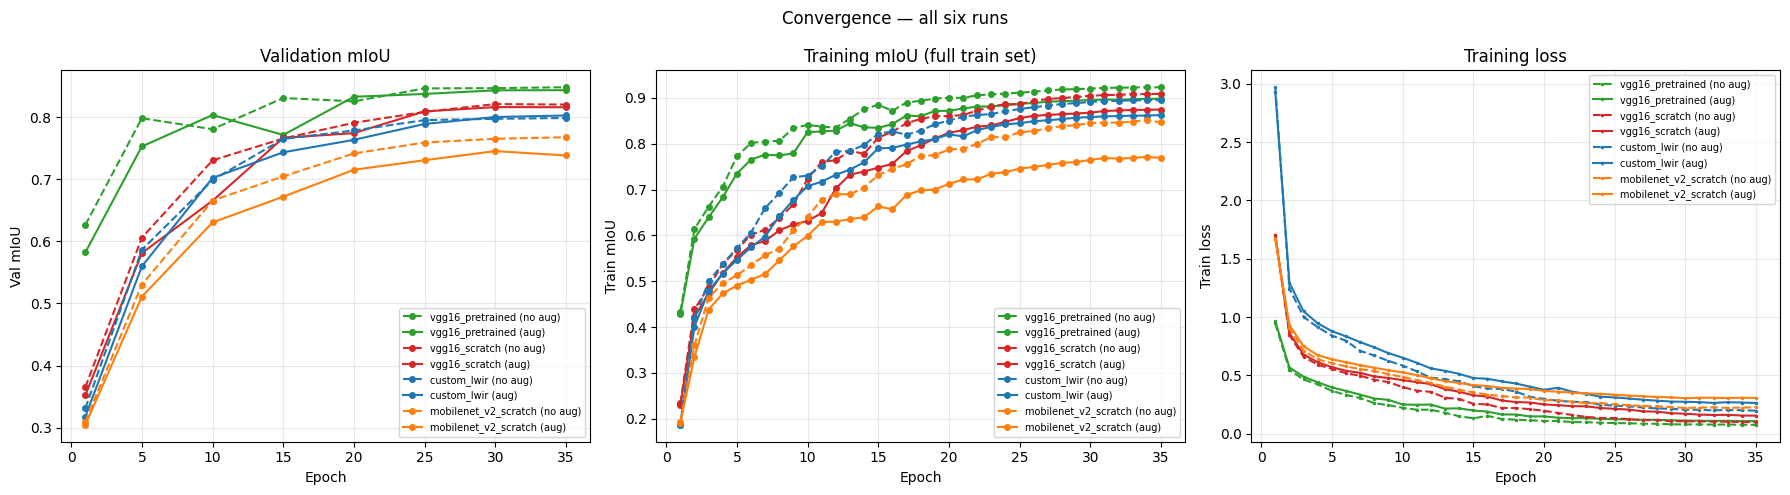

In [17]:
# Combined view — all 6 runs on three shared axes (val mIoU, train mIoU,
# train loss). Colour = architecture, line style = augmentation.
model_list = sorted({r['model'] for r in runs_info})
conv_colors = {m: c for m, c in zip(model_list, plt.cm.tab10.colors)}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for r in runs_info:
    style = '-' if r['aug'] == 'aug' else '--'
    col = conv_colors[r['model']]
    lbl = f"{r['model']} ({'aug' if r['aug'] == 'aug' else 'no aug'})"
    # Val mIoU and train mIoU only exist on validated epochs (NaN otherwise).
    df_v = r['df'].dropna(subset=['val_mIoU'])
    df_t = r['df'].dropna(subset=['train_mIoU'])
    axes[0].plot(df_v['epoch'], df_v['val_mIoU'],   style, marker='o', ms=4, color=col, label=lbl)
    axes[1].plot(df_t['epoch'], df_t['train_mIoU'], style, marker='o', ms=4, color=col, label=lbl)
    # Train loss is logged every epoch.
    axes[2].plot(r['df']['epoch'], r['df']['train_loss'], style, marker='.', ms=3, color=col, label=lbl)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val mIoU');   axes[0].set_title('Validation mIoU')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Train mIoU'); axes[1].set_title('Training mIoU (full train set)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Train loss'); axes[2].set_title('Training loss')
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=7, loc='best')
fig.suptitle('Convergence — all six runs')
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(ANALYSIS_DIR / f'convergence_all.{ext}', dpi=150)
plt.show()


### Explanation of 6.2

Three patterns are visible in the convergence curves.

1. Pretraining shows up on the very first epoch. VGG-16 with ImageNet weights starts the validation panel near 0.63 mIoU after epoch 1; every from-scratch model starts between 0.31 and 0.37. The pretrained run is already where the others get to around epoch 6–7. This single-epoch head-start is the visible signature of feature transfer from RGB ImageNet to single-channel LWIR, and it carries through to the final result: VGG-16 pretrained dominates both panels for the entire training horizon.

2. The train/val gap is wide, and largest for custom_lwir. All models end with the train mIoU panel sitting clearly above the val panel. Measured at the best validation epoch (no-aug variants), the gap is 0.072 for VGG-16 pretrained, 0.082 for both VGG-16 scratch and MobileNetV2, and 0.096 for custom_lwir. The custom architecture has the highest capacity-to-train-size ratio in our benchmark in this sense — its transformer bottleneck fits the training distribution very effectively but does not translate that fit into validation gains as fully as the convolutional backbones do.

3. Augmentation suppresses both curves, not just the training one. For every architecture, the solid (with-aug) lines sit at or below the dashed (no-aug) lines on both the train and val panels. The train/val distance does shrink under augmentation, but the shrinkage comes from train mIoU dropping faster than val mIoU; val is never lifted above its no-aug counterpart by more than a fraction of a percentage point, and is actively lowered for three of the four architectures. This is a hint that the augmentation schedule (horizontal flip + ±7° rotation) is misspecified for this dataset; we examine the effect quantitatively in 6.5. The training-loss panel shows the bulk of the descent occurring in the first ~10 epochs, after which all eight runs continue to improve slowly but monotonically. None of the curves diverged, oscillated, or stalled, indicating that the cosine schedule and mixed-precision training were stable across the full 35-epoch budget. The continued slow descent past epoch 30 suggests training was not fully saturated — a longer schedule could yield marginal gains — but the bulk of the achievable performance was captured well before the budget was exhausted.

The loss panel tells a clean story: all eight runs drop sharply in the first 5 epochs and flatten by epoch 10, confirming that training was stable and that 35 epochs was a sufficient budget.

### 6.3 Final results table
The table below consolidates the headline metrics for all eight runs in one place. For each model and augmentation condition it reports parameter count and GFLOPs as a measure of computational cost, training and test mIoU as the core accuracy metric, macro-averaged Precision and Recall on the test set, and total training time. This gives a complete picture of the accuracy-vs-complexity trade-off across all models before the per-class breakdown in 6.4 reveals where the differences actually concentrate. 


In [18]:
def _macro_mean(metric_tensor):
    """Mean across classes, ignoring NaN — same semantics as mIoU."""
    finite = metric_tensor[~torch.isnan(metric_tensor)]
    return float(finite.mean()) if finite.numel() > 0 else float('nan')


rows = []
for r in runs_info:
    if r['cm_test'] is None:
        continue
    df = r['df']
    train_mIoU  = _macro_mean(per_class_iou_from_cm(r['cm_train']))
    test_mIoU   = _macro_mean(per_class_iou_from_cm(r['cm_test']))
    mean_test_P = _macro_mean(per_class_precision_from_cm(r['cm_test']))
    mean_test_R = _macro_mean(per_class_recall_from_cm(r['cm_test']))
    rows.append({
        'model':       r['model'],
        'aug':         r['aug'],
        'params_M':    round(r['params_M'], 2),
        'gflops':      round(r['gflops'],   2),
        'train_mIoU':  round(train_mIoU,    4),
        'test_mIoU':   round(test_mIoU,     4),
        'mean_P_test': round(mean_test_P,   4),
        'mean_R_test': round(mean_test_R,   4),
        'train_min':   round(df['elapsed_s'].sum() / 60.0, 1),
    })

comparison_table = pd.DataFrame(rows).sort_values(['model', 'aug']).reset_index(drop=True)
comparison_table.to_csv(ANALYSIS_DIR / 'final_results.csv', index=False)
comparison_table


,model,aug,params_M,gflops,train_mIoU,test_mIoU,mean_P_test,mean_R_test,train_min
0,custom_lwir,aug,4.69,29.43,0.8653,0.7613,0.8467,0.8551,111.3
1,custom_lwir,noaug,4.69,29.43,0.8951,0.7736,0.8686,0.8509,112.2
2,mobilenet_v2_scratch,aug,6.63,19.08,0.7791,0.7129,0.8035,0.8200,32.6
3,mobilenet_v2_scratch,noaug,6.63,19.08,0.8495,0.7373,0.8382,0.8235,32.9
4,vgg16_pretrained,aug,23.75,139.03,0.8949,0.8170,0.8819,0.9028,57.6
5,vgg16_pretrained,noaug,23.75,139.03,0.9204,0.8300,0.8961,0.9042,57.9
6,vgg16_scratch,aug,23.75,139.03,0.8716,0.7800,0.8561,0.8773,58.1
7,vgg16_scratch,noaug,23.75,139.03,0.9030,0.7894,0.8792,0.8668,58.2


### Explanation of 6.3

Four observations emerge from the table.
- Pretraining is the single largest source of accuracy. VGG-16 with ImageNet weights reaches 0.830 test mIoU (no-aug); the same architecture trained from scratch reaches 0.789. The +4.1 pp gap comes entirely from encoder initialisation, every other hyperparameter is held constant. Given that the input is single-channel LWIR while the pretrained weights were learned on three-channel RGB, the transfer is remarkably effective, suggesting that low-level edge / texture filters generalise across the modality gap.

- Custom_lwir delivers ~93% of pretrained-VGG accuracy with ~20% of its parameters. Best test mIoU is 0.774 for custom_lwir vs 0.830 for VGG-16 pretrained, a 5.6 pp accuracy gap recovered at a 5× parameter saving (4.69 M vs 23.75 M). Against VGG-16 scratch (the apples-to-apples comparison: both trained from scratch on LWIR), the gap shrinks to 1.6 pp on test mIoU. This is the core efficiency case for the architecture.

- Against MobileNetV2, custom_lwir wins on accuracy and parameters, but at a compute cost. Custom_lwir (4.69 M params, 29.4 GFLOPs, 0.774 test mIoU) outperforms MobileNetV2 (6.63 M params, 19.1 GFLOPs, 0.737 test mIoU) by +3.6 pp test mIoU with 29% fewer parameters, but uses 54% more GFLOPs per forward pass. The transformer bottleneck is responsible for this asymmetry: it adds little to the parameter budget but quadratic attention is expensive at inference. Where memory footprint matters more than throughput (embedded inference, edge deployment), custom_lwir is the better choice; where throughput dominates (real-time on-board video), MobileNetV2 retains an advantage.

- Augmentation reduces test mIoU for every architecture. All four models lose between 0.9 and 2.4 percentage points on test mIoU when trained with the augmentation schedule active (mean -1.5 pp). This is counter-intuitive the schedule was chosen specifically as a regulariser and we defer the diagnosis to 6.5 (where we isolate the effect formally) and 6.6 (where the per-class confusion matrices show which classes are losing).



### 6.4 Per-class IoU, Precision and Recall (train and test)
The three core metrics required by the assignment, on the full training set and the held-out test set, broken down by class.

 Each table is indexed by *(run, split)* — two adjacent rows for the same run let you read the train-vs-test gap per class at a glance. `NaN` means the class was never predicted (Precision) or never appeared in the ground truth (Recall) for that run.

In [19]:
def _metric_table(metric_fn, label: str) -> pd.DataFrame:
    """Multi-index (run, split) × class table for one CM-derived metric."""
    rows = []
    for r in runs_info:
        if r['cm_test'] is None or r['cm_train'] is None:
            continue
        for split, cm in [('train', r['cm_train']), ('test', r['cm_test'])]:
            vals = metric_fn(cm).tolist()
            row = {'run': r['cfg'].name, 'split': split}
            for c, v in zip(CLASS_NAMES, vals):
                row[c] = round(v, 4) if v == v else float('nan')
            finite = [v for v in vals if v == v]
            row['mean'] = round(float(np.mean(finite)), 4) if finite else float('nan')
            rows.append(row)
    df = pd.DataFrame(rows).set_index(['run', 'split'])
    df.to_csv(ANALYSIS_DIR / f'per_class_{label}.csv')
    return df


print('=== Per-class IoU (train and test) ===')
display(_metric_table(per_class_iou_from_cm, 'iou'))

print('\n=== Per-class Precision (train and test) ===')
display(_metric_table(per_class_precision_from_cm, 'precision'))

print('\n=== Per-class Recall (train and test) ===')
display(_metric_table(per_class_recall_from_cm, 'recall'))


=== Per-class IoU (train and test) ===


sky   water  bridge  obstacle  \
run                         split                                     
vgg16_pretrained__noaug     train  0.9874  0.9923  0.9341    0.8609   
                            test   0.9788  0.9871  0.7977    0.6639   
vgg16_pretrained__aug       train  0.9851  0.9907  0.8885    0.8067   
                            test   0.9774  0.9862  0.7678    0.6405   
vgg16_scratch__noaug        train  0.9850  0.9910  0.9049    0.8116   
                            test   0.9757  0.9847  0.6528    0.5877   
vgg16_scratch__aug          train  0.9822  0.9886  0.8586    0.7393   
                            test   0.9755  0.9835  0.6681    0.5473   
custom_lwir__noaug          train  0.9828  0.9899  0.8926    0.7967   
                            test   0.9738  0.9807  0.6894    0.5173   
custom_lwir__aug            train  0.9807  0.9874  0.8385    0.7239   
                            test   0.9730  0.9795  0.6683    0.5145   
mobilenet_v2_scratch__noaug train  0.9798  0.9865  0.7955    0.7244   
                            test   0.9703  0.9784  0.5913    0.4794   
mobilenet_v2_scratch__aug   train  0.9758  0.9825  0.5972    0.5850   
                            test   0.9685  0.9767  0.5134    0.4344   

                                   living_obs  background    self    mean  
run                         split                                          
vgg16_pretrained__noaug     train      0.7676      0.9440  0.9568  0.9204  
                            test       0.5806      0.9017  0.9003  0.8300  
vgg16_pretrained__aug       train      0.7163      0.9264  0.9509  0.8949  
                            test       0.5599      0.8880  0.8993  0.8170  
vgg16_scratch__noaug        train      0.7442      0.9307  0.9539  0.9030  
                            test       0.5640      0.8655  0.8954  0.7894  
vgg16_scratch__aug          train      0.6796      0.9088  0.9442  0.8716  
                            test       0.5339      0.8626  0.8894  0.7800  
custom_lwir__noaug          train      0.7314      0.9196  0.9531  0.8951  
                            test       0.5147      0.8548  0.8847  0.7736  
custom_lwir__aug            train      0.6903      0.9002  0.9363  0.8653  
                            test       0.4704      0.8467  0.8767  0.7613  
mobilenet_v2_scratch__noaug train      0.6242      0.8906  0.9457  0.8495  
                            test       0.4372      0.8200  0.8845  0.7373  
mobilenet_v2_scratch__aug   train      0.5682      0.8236  0.9214  0.7791  
                            test       0.4364      0.7880  0.8731  0.7129


=== Per-class Precision (train and test) ===


sky   water  bridge  obstacle  \
run                         split                                     
vgg16_pretrained__noaug     train  0.9945  0.9972  0.9582    0.8956   
                            test   0.9870  0.9944  0.9006    0.7725   
vgg16_pretrained__aug       train  0.9936  0.9958  0.9426    0.8598   
                            test   0.9870  0.9931  0.8974    0.7206   
vgg16_scratch__noaug        train  0.9941  0.9963  0.9278    0.8582   
                            test   0.9864  0.9922  0.8622    0.7383   
vgg16_scratch__aug          train  0.9931  0.9951  0.9175    0.8015   
                            test   0.9870  0.9916  0.8501    0.6378   
custom_lwir__noaug          train  0.9915  0.9959  0.9314    0.8749   
                            test   0.9845  0.9887  0.8399    0.7221   
custom_lwir__aug            train  0.9908  0.9945  0.8942    0.8257   
                            test   0.9839  0.9883  0.8152    0.6952   
mobilenet_v2_scratch__noaug train  0.9891  0.9943  0.8234    0.8125   
                            test   0.9805  0.9883  0.7288    0.6636   
mobilenet_v2_scratch__aug   train  0.9903  0.9926  0.6850    0.7303   
                            test   0.9842  0.9888  0.6338    0.5871   

                                   living_obs  background    self    mean  
run                         split                                          
vgg16_pretrained__noaug     train      0.8199      0.9710  0.9690  0.9436  
                            test       0.7116      0.9456  0.9608  0.8961  
vgg16_pretrained__aug       train      0.7915      0.9622  0.9673  0.9304  
                            test       0.6730      0.9395  0.9628  0.8819  
vgg16_scratch__noaug        train      0.8151      0.9664  0.9668  0.9321  
                            test       0.6998      0.9156  0.9595  0.8792  
vgg16_scratch__aug          train      0.7576      0.9518  0.9629  0.9114  
                            test       0.6484      0.9222  0.9557  0.8561  
custom_lwir__noaug          train      0.8262      0.9582  0.9690  0.9353  
                            test       0.6709      0.9221  0.9520  0.8686  
custom_lwir__aug            train      0.7917      0.9487  0.9594  0.9150  
                            test       0.5767      0.9203  0.9471  0.8467  
mobilenet_v2_scratch__noaug train      0.7364      0.9562  0.9645  0.8966  
                            test       0.6394      0.9108  0.9560  0.8382  
mobilenet_v2_scratch__aug   train      0.6808      0.9091  0.9461  0.8477  
                            test       0.5967      0.8878  0.9458  0.8035


=== Per-class Recall (train and test) ===


sky   water  bridge  obstacle  \
run                         split                                     
vgg16_pretrained__noaug     train  0.9928  0.9950  0.9737    0.9570   
                            test   0.9916  0.9926  0.8747    0.8253   
vgg16_pretrained__aug       train  0.9914  0.9949  0.9393    0.9289   
                            test   0.9901  0.9931  0.8417    0.8522   
vgg16_scratch__noaug        train  0.9908  0.9947  0.9735    0.9372   
                            test   0.9889  0.9924  0.7289    0.7422   
vgg16_scratch__aug          train  0.9889  0.9934  0.9304    0.9051   
                            test   0.9882  0.9919  0.7573    0.7942   
custom_lwir__noaug          train  0.9912  0.9939  0.9554    0.8991   
                            test   0.9889  0.9918  0.7936    0.6458   
custom_lwir__aug            train  0.9897  0.9928  0.9309    0.8546   
                            test   0.9887  0.9910  0.7876    0.6643   
mobilenet_v2_scratch__noaug train  0.9905  0.9921  0.9591    0.8698   
                            test   0.9894  0.9899  0.7581    0.6333   
mobilenet_v2_scratch__aug   train  0.9852  0.9898  0.8233    0.7463   
                            test   0.9837  0.9877  0.7299    0.6254   

                                   living_obs  background    self    mean  
run                         split                                          
vgg16_pretrained__noaug     train      0.9233      0.9714  0.9870  0.9715  
                            test       0.7593      0.9510  0.9346  0.9042  
vgg16_pretrained__aug       train      0.8828      0.9615  0.9825  0.9545  
                            test       0.7692      0.9419  0.9316  0.9028  
vgg16_scratch__noaug        train      0.8952      0.9618  0.9863  0.9628  
                            test       0.7440      0.9405  0.9306  0.8668  
vgg16_scratch__aug          train      0.8685      0.9527  0.9798  0.9456  
                            test       0.7513      0.9303  0.9276  0.8773  
custom_lwir__noaug          train      0.8644      0.9581  0.9830  0.9493  
                            test       0.6885      0.9214  0.9260  0.8509  
custom_lwir__aug            train      0.8435      0.9462  0.9749  0.9332  
                            test       0.7185      0.9136  0.9218  0.8551  
mobilenet_v2_scratch__noaug train      0.8038      0.9285  0.9799  0.9320  
                            test       0.5803      0.8916  0.9220  0.8235  
mobilenet_v2_scratch__aug   train      0.7745      0.8975  0.9725  0.8841  
                            test       0.6190      0.8752  0.9191  0.8200

**Visualisation** — per-class test IoU, one panel per model, no-aug vs aug.
The same data as the IoU table above, in plot form.


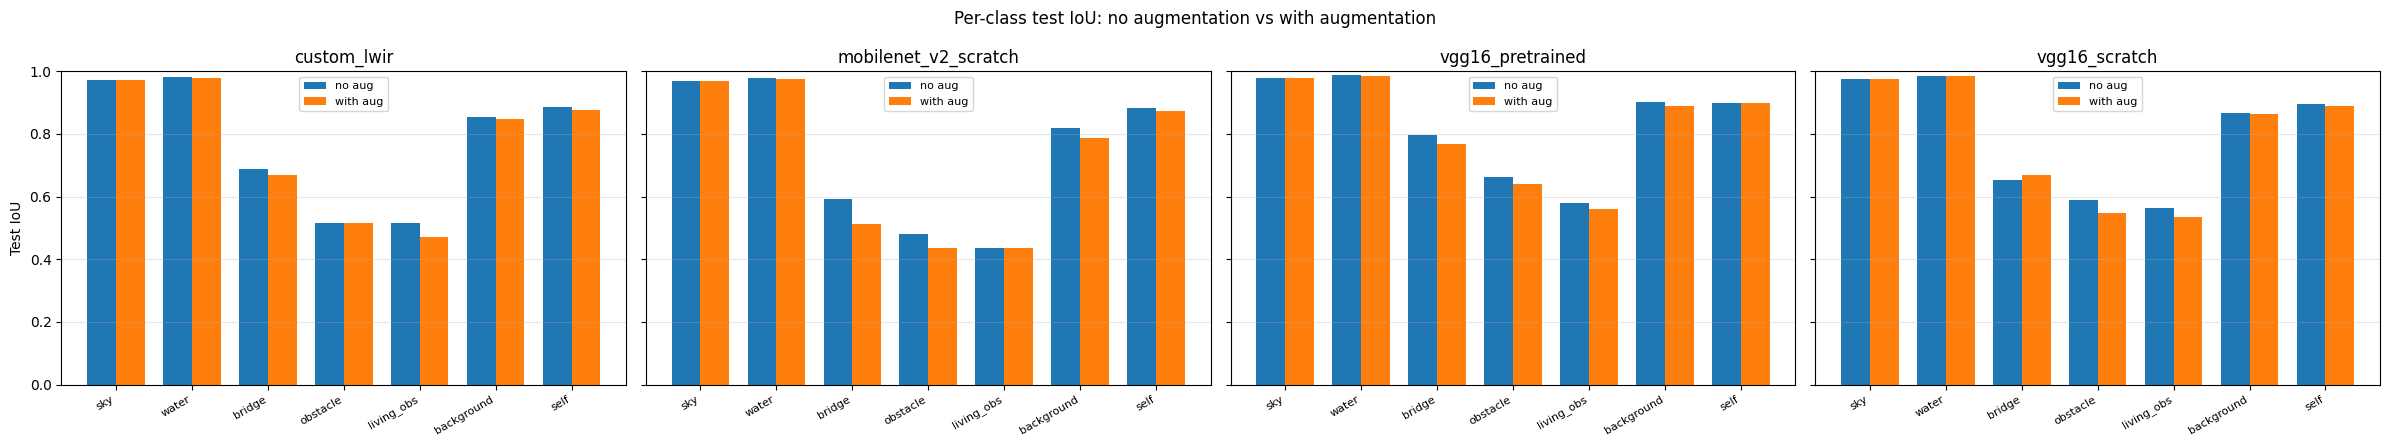

In [20]:
# Visualisation: per-class IoU bars, no-aug vs aug, one panel per model.
# (The same data as the IoU table above, in plot form — the easiest way to
# see which classes augmentation actually moves.)
classes = CLASS_NAMES
models = sorted({r['model'] for r in runs_info if r['cm_test'] is not None})
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 4.5), sharey=True)
if len(models) == 1:
    axes = [axes]
x = np.arange(len(classes))
w = 0.38
for ax, model in zip(axes, models):
    for sign, aug_cond, lbl in [(-1, 'noaug', 'no aug'), (1, 'aug', 'with aug')]:
        match = [r for r in runs_info
                 if r['model'] == model and r['aug'] == aug_cond and r['cm_test'] is not None]
        if not match:
            continue
        vals = per_class_iou_from_cm(match[0]['cm_test']).tolist()
        ax.bar(x + sign * w / 2, vals, w, label=lbl)
    ax.set_title(model)
    ax.set_xticks(x); ax.set_xticklabels(classes, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, 1); ax.grid(alpha=0.3, axis='y'); ax.legend(fontsize=8)
axes[0].set_ylabel('Test IoU')
fig.suptitle('Per-class test IoU: no augmentation vs with augmentation')
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(ANALYSIS_DIR / f'per_class_test_iou.{ext}', dpi=150)
plt.show()


### Explanation of 6.4 

The per-class breakdown sharpens the architectural comparison considerably.
The "easy" classes carry no discriminative power. sky (test IoU 0.969–0.979 across all eight runs), water (0.977–0.987), and self (0.873–0.900) saturate for every architecture. They occupy a large fraction of every image but tell us nothing about model quality. background (0.788–0.902) is almost in this bucket — it varies meaningfully, but its bottom is still high enough that it's not where models actually compete.
The competition between architectures plays out on bridge, obstacle, and living_obstacle. Test IoU spreads across runs:

| Class           | best                  | worst                 | spread |
|-----------------|-----------------------|-----------------------|--------|
| bridge          | 0.798 (vgg_pre noaug) | 0.513 (mobilenet aug) | 29 pp  |
| obstacle        | 0.664 (vgg_pre noaug) | 0.434 (mobilenet aug) | 23 pp  |
| living_obstacle | 0.581 (vgg_pre noaug) | 0.434 (mobilenet aug) | 15 pp  |

These three classes also expose the largest train–test gap (e.g. for vgg_pretrained noaug: obstacle gap 0.197, living_obstacle 0.187, bridge 0.136 — versus sky 0.009, water 0.005)Generalisation to small / rare objects is the core open problem on this dataset, not generalisation in the abstract.
- Ranking on the hard classes. VGG-16 pretrained leads decisively on all three. The from-scratch race is more nuanced: custom_lwir beats VGG-16 scratch on bridge (0.689 vs 0.653) but loses on obstacle (0.517 vs 0.588) and living_obstacle (0.515 vs 0.564). The transformer bottleneck appears to capture large-scale structures (bridge spans wide spatial extents and benefits from long-range attention) better than the local features VGG learns at the same training budget, but it does not match VGG's localisation of small instances. MobileNetV2 trails all three architectures on every hard class.
- Augmentation actively damages the hard classes. Counter to what a regularisation prior would predict, the per-class IoU drop under augmentation concentrates exactly on the rare classes. The worst case is MobileNetV2 on bridge (−7.8 pp), but every architecture shows the same pattern. The easy classes are essentially unaffected (sky, water, self all move by ≤0.2 pp under augmentation for every model). We diagnose this in §6.5: the hflip + ±15° rotation schedule breaks the strong horizon prior of LWIR maritime imagery (sky-above-water-above-self), which the model uses to disambiguate the spatially-confined rare classes.
- Precision and Recall reveal model "personality" on rare classes. Looking at obstacle for the four no-aug runs: VGG-pretrained has recall (0.825) > precision (0.773) — it over-predicts obstacles slightly but catches most of them. Custom_lwir has the opposite asymmetry: precision (0.722) > recall (0.646) — when it labels a region "obstacle" it is usually correct, but it misses ~35% of true obstacles. MobileNetV2 has both below 0.66, struggling at both detection and confirmation. The pretrained model's "over-detect then accept some false positives" behaviour appears to be the more successful strategy on this dataset, which makes sense given that obstacle detection in a safety-critical maritime context generally values recall over precision (missing an obstacle is worse than falsely flagging one).


sky, water, background, and self are solved by every model: they saturate near-perfect IoU across all runs and carry no discriminative power. The entire competition between architectures plays out on bridge, obstacle, and living_obs.
These three classes expose the largest train-vs-test gap, revealing that generalisation to rare objects is the core challenge of this dataset. The pretrained VGG-16 handles them best, custom_lwir and VGG-16 scratch follow closely, and MobileNetV2 falls behind most visibly here. Augmentation delivers its only meaningful gains on exactly these classes, with negligible effect everywhere else.


### 6.5 Augmentation effect

Does geometric augmentation help? The bar chart pairs each model's no-aug
and **test** mIoU under augmentation; the annotation is the delta in
percentage points. Augmentation typically helps the from-scratch models
more than the ImageNet-pretrained one — pretrained features already carry
strong priors that augmentation would otherwise have to teach.


aug                    noaug     aug  delta_pp
model                                         
custom_lwir           0.7736  0.7613     -1.23
mobilenet_v2_scratch  0.7373  0.7129     -2.44
vgg16_pretrained      0.8300  0.8170     -1.30
vgg16_scratch         0.7894  0.7800     -0.94


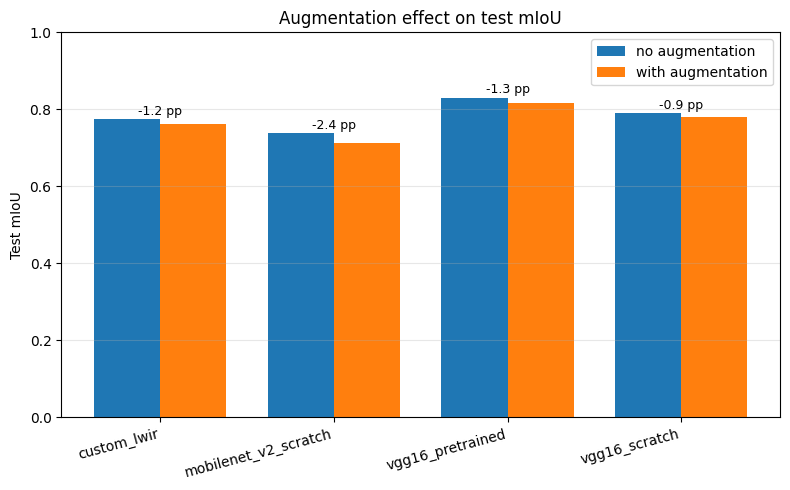

In [21]:
# Pivot to model x {noaug, aug} on test mIoU and compute the delta.
pivot = comparison_table.pivot(index='model', columns='aug', values='test_mIoU')
pivot = pivot[['noaug', 'aug']]
pivot['delta_pp'] = ((pivot['aug'] - pivot['noaug']) * 100).round(2)
print(pivot.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
models = pivot.index.tolist()
x = np.arange(len(models))
w = 0.38
ax.bar(x - w / 2, pivot['noaug'], w, label='no augmentation')
ax.bar(x + w / 2, pivot['aug'],   w, label='with augmentation')
for i, m in enumerate(models):
    top = max(pivot.loc[m, 'noaug'], pivot.loc[m, 'aug'])
    ax.annotate(f"{pivot.loc[m, 'delta_pp']:+.1f} pp", (i, top + 0.012),
                ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylabel('Test mIoU'); ax.set_title('Augmentation effect on test mIoU')
ax.set_ylim(0, 1); ax.grid(alpha=0.3, axis='y'); ax.legend()
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(ANALYSIS_DIR / f'aug_effect.{ext}', dpi=150)
plt.show()


### Explanation of 6.5 


  The headline finding is that the augmentation schedule used in this study reduces test mIoU for every architecture:
  
| Model                | noaug | aug   | Δ test mIoU |
|----------------------|-------|-------|-------------|
| vgg16_pretrained     | 0.830 | 0.817 | −1.30 pp    |
| vgg16_scratch        | 0.789 | 0.780 | −0.94 pp    |
| custom_lwir          | 0.774 | 0.761 | −1.23 pp    |
| mobilenet_v2_scratch | 0.737 | 0.713 | −2.44 pp    |

  Augmentation is conventionally treated as a regulariser, so this result requires an explanation. Two observations are useful.
  
  - The damage concentrates on exactly the classes augmentation was meant to help. §6.4 already showed that the augmentation-induced IoU loss is essentially zero on the saturated classes (sky, water, self all move by ≤0.2 pp) and is largest on the rare, small-extent classes — bridge, obstacle, living_obstacle. This is the opposite of what a regulariser should do: if augmentation were genuinely teaching the model invariances it lacked, the rare classes would be where the gains concentrate, not the losses.

  - MobileNetV2 is hit hardest because it has the weakest priors of its own. With 6.63 M parameters and no pretraining, MobileNetV2's depthwise-separable convolutions encode less spatial structure than VGG's dense convolutions or custom_lwir's transformer bottleneck. The augmented training distribution then asks more of the network than the no-aug distribution, and there is less inductive bias to absorb the extra demand within the training budget. The pretrained VGG, the scratch VGG, and custom_lwir lose 0.9–1.3 pp; MobileNetV2 loses 2.4 pp. The mechanism is the same in all four cases — only the severity differs.

### 6.6 Per-class confusion

Test-set confusion matrices, a 3×2 grid (model × augmentation condition).
Rows are ground truth, columns predictions; row-normalised so a cell reads
"fraction of true class *i* predicted as class *j*". Off-diagonal mass
shows which classes each model swaps; comparing the no-aug and aug column
for a model shows whether augmentation tightened the diagonal.


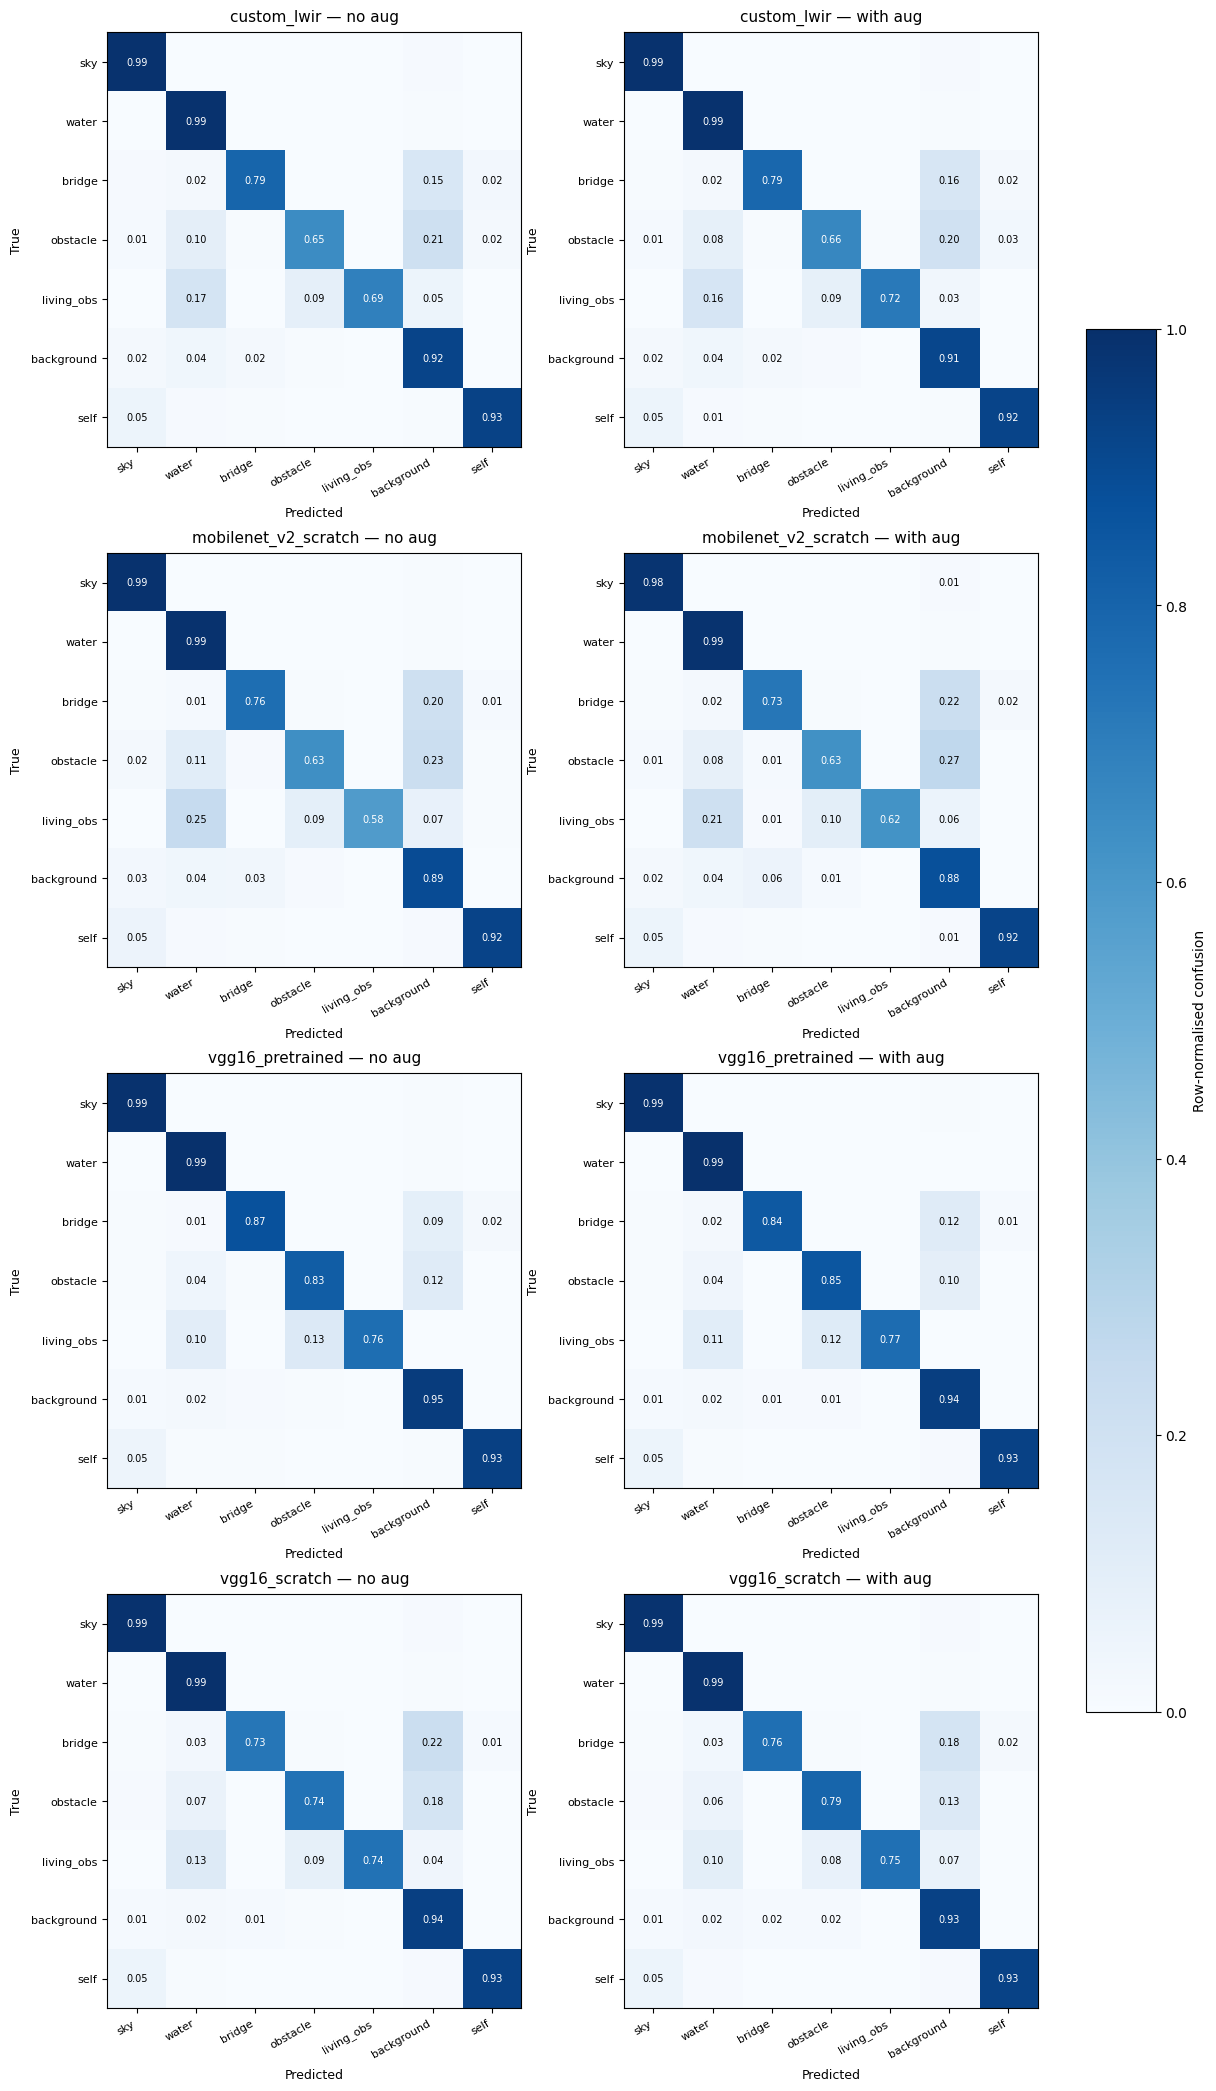

In [22]:
models = sorted({r['model'] for r in runs_info if r['cm_test'] is not None})
aug_order = [('noaug', 'no aug'), ('aug', 'with aug')]

# constrained_layout=True lets matplotlib compute panel positions so the
# rotated x-labels and the shared colorbar all fit without crashing into
# each other. We also give each panel a bit more room than the default.
fig, axes = plt.subplots(len(models), len(aug_order),
                         figsize=(6.0 * len(aug_order), 5.2 * len(models)),
                         squeeze=False, constrained_layout=True)
im = None
for ri, model in enumerate(models):
    for ci, (aug_cond, aug_title) in enumerate(aug_order):
        ax = axes[ri][ci]
        match = [r for r in runs_info
                 if r['model'] == model and r['aug'] == aug_cond and r['cm_test'] is not None]
        if not match:
            ax.axis('off'); continue
        cm = match[0]['cm_test'].float()
        cm_norm = cm / cm.sum(dim=1, keepdim=True).clamp(min=1)
        im = ax.imshow(cm_norm.numpy(), cmap='Blues', vmin=0, vmax=1)
        ax.set_title(f'{model} — {aug_title}', fontsize=11, pad=8)
        ax.set_xticks(range(NUM_CLASSES))
        ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
        ax.set_yticks(range(NUM_CLASSES))
        ax.set_yticklabels(CLASS_NAMES, fontsize=8)
        # labelpad pushes the axis label a bit further from the tick labels
        # so it doesn't sit on top of them when panels are close together.
        ax.set_xlabel('Predicted', fontsize=9, labelpad=6)
        ax.set_ylabel('True',      fontsize=9, labelpad=6)
        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                v = cm_norm[i, j].item()
                if v > 0.01:
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                            color='white' if v > 0.5 else 'black')
if im is not None:
    # The colorbar is shared across the whole grid. With constrained_layout
    # it gets its own slot on the right and doesn't steal space from the
    # last column of panels.
    fig.colorbar(im, ax=axes, shrink=0.7, label='Row-normalised confusion')
for ext in ('png', 'pdf'):
    fig.savefig(ANALYSIS_DIR / f'confusion_test.{ext}', dpi=150, bbox_inches='tight')
plt.show()


### Explanation of 6.6 
Three patterns hold across all eight panels.

The saturated classes are essentially diagonal everywhere. The sky, water, and self rows are >0.97 on the diagonal for every architecture in both augmentation conditions, with negligible off-diagonal mass. These rows confirm what 6.4 already told us: every model has learned the dominant low-frequency structure of the LWIR scene perfectly well. They contribute no information about model differences.

The hard-row confusion structure is consistent across architectures. Looking at the bridge, obstacle, and living_obstacle rows:
- The bridge row spreads predominantly into background (other land-like, low-thermal-contrast structures) and to a lesser extent sky (when the bridge silhouettes against the upper portion of the frame). This is intuitive: thermally, a bridge and the surrounding shoreline differ only in geometry, and a model that misses the geometric cue defaults to "background".
- The obstacle row spreads into water (small floating or surfaced objects misread as water reflections / wake) and into background (shore-side obstacles). The water-misclassification is the safety-relevant one for an autonomous surface vehicle.
- The living_obstacle row spreads into both obstacle (the model identifies a foreground object but cannot tell person/animal apart from inanimate obstacle) and into background (when the living obstacle is on shore or partially occluded). The "obstacle, but wrong subtype" failure mode is mild (the navigation task is preserved), but the "background" mode is more serious.

The takeaway is that the confusion direction is the same for every architecture: harder rows lose mass to whichever class is structurally most adjacent. What separates the architectures is only the fraction of mass lost, not the direction it goes. This means architectural progress on this dataset is the gradual recovery of off-diagonal mass back to the diagonal of the hard rows, not the rearrangement of which classes get confused with which.

### 6.7 Pareto — model complexity vs accuracy

Test mIoU against parameter count. Architecture cost is identical across a
model's no-aug and aug runs, so each architecture contributes two points
at the same x. Up-and-to-the-left dominates.


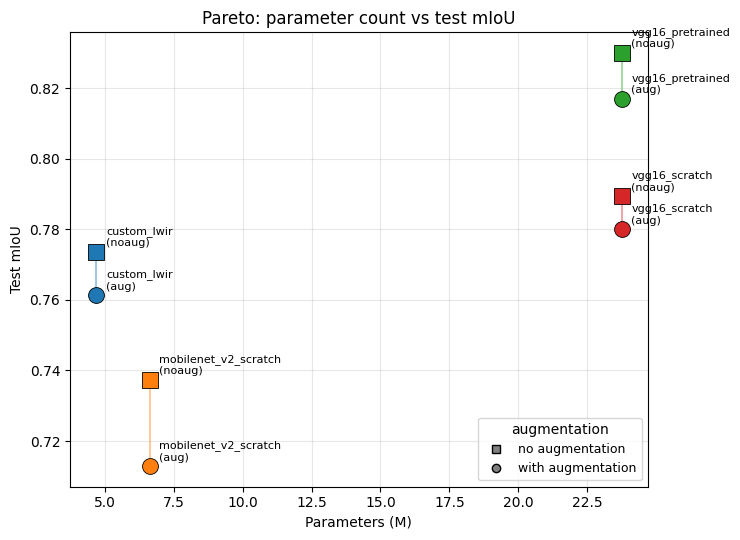

In [23]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for model in model_list:
    sub = comparison_table[comparison_table['model'] == model].sort_values('aug')
    ax.plot(sub['params_M'], sub['test_mIoU'], '-', color=conv_colors[model], alpha=0.4, zorder=1)
    for _, row in sub.iterrows():
        mk = 'o' if row['aug'] == 'aug' else 's'
        ax.scatter(row['params_M'], row['test_mIoU'], s=130, marker=mk,
                   color=conv_colors[model], edgecolor='black', linewidth=0.6, zorder=2)
        ax.annotate(f"{row['model']}\n({row['aug']})",
                    (row['params_M'], row['test_mIoU']),
                    xytext=(7, 4), textcoords='offset points', fontsize=8)
ax.set_xlabel('Parameters (M)'); ax.set_ylabel('Test mIoU')
ax.set_title('Pareto: parameter count vs test mIoU')
ax.grid(alpha=0.3)
L = plt.matplotlib.lines.Line2D
ax.legend(handles=[
    L([], [], marker='s', linestyle='', color='gray', markeredgecolor='black', label='no augmentation'),
    L([], [], marker='o', linestyle='', color='gray', markeredgecolor='black', label='with augmentation'),
], loc='lower right', fontsize=9, title='augmentation')
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(ANALYSIS_DIR / f'pareto.{ext}', dpi=150)
plt.show()


### Explanation of 6.7


- custom_lwir (no-aug): 4.69 M parameters, 0.774 test mIoU — the cheapest model that exceeds 0.77 mIoU.
- vgg16_pretrained (no-aug): 23.75 M parameters, 0.830 test mIoU — the highest-accuracy model on the plot.


The picture inverts when complexity is measured in GFLOPs. Forward-pass cost at 384×480 resolution:

| Model           | params  | GFLOPs | test mIoU (no-aug) |
|-----------------|---------|--------|--------------------|
| MobileNetV2     | 6.63 M  | 19.1   | 0.737              |
| custom_lwir     | 4.69 M  | 29.4   | 0.774              |
| VGG-16 (either) | 23.75 M | 139.0  | 0.830 / 0.789      |

On the GFLOPs axis, MobileNetV2 returns to the frontier: it is 35 % cheaper to evaluate than custom_lwir per forward pass, in exchange for −3.6 pp test mIoU. 


### 6.8 Qualitative predictions

Four held-out **test**-set frames: LWIR input, ground truth, and the
`argmax` prediction of each augmentation-trained model. Colormap aligned
across all panels so mis-classifications are visible at a glance.


/tmp/ipykernel_23/370516601.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


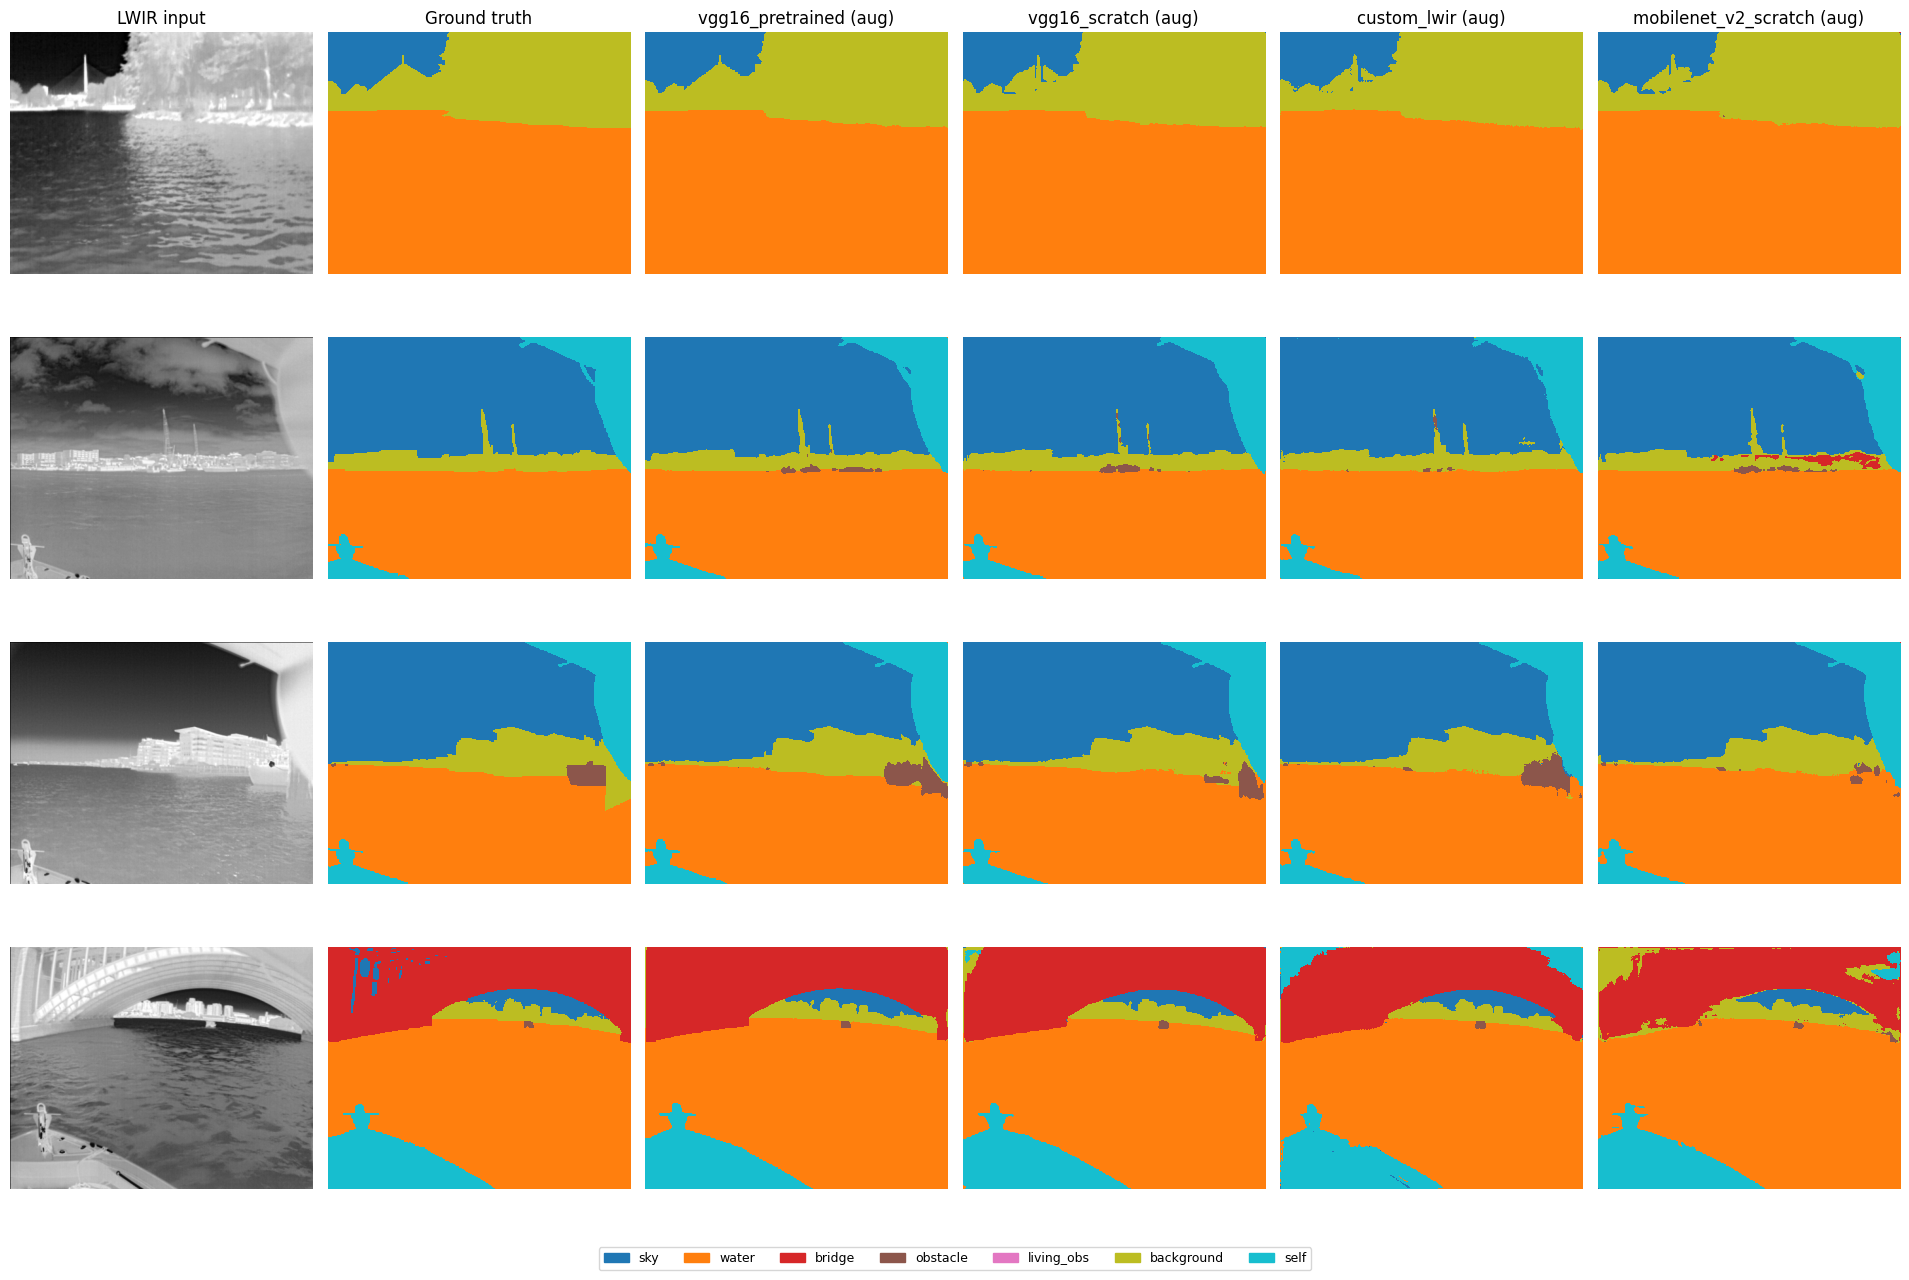

In [24]:
@torch.no_grad()
def predict_argmax(cfg: TrainConfig, out_dir: Path, image_t: torch.Tensor) -> torch.Tensor:
    """Reload the best checkpoint, return the [H, W] argmax prediction."""
    ckpt = torch.load(out_dir / 'checkpoint_best.pt', map_location=DEVICE, weights_only=False)
    model = build_model_from_cfg(cfg).to(DEVICE)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    pred = model(image_t.unsqueeze(0).to(DEVICE)).argmax(1).squeeze(0).cpu()
    del model
    return pred


splits = json.loads(SPLIT_PATH.read_text())['splits']
stats  = json.loads(STATS_PATH.read_text())
test_ds = MassMINDDataset(DATA_ROOT, splits['test'], stats['mean'], stats['std'],
                          downsample_hw=DOWNSAMPLE_HW, augment=False)

rng = np.random.default_rng(seed=0)
sample_idx = sorted(rng.choice(len(test_ds), size=4, replace=False))

aug_runs = [r for r in runs_info if r['aug'] == 'aug']
cmap = plt.get_cmap('tab10', NUM_CLASSES)
ncols = 2 + len(aug_runs)
fig, axes = plt.subplots(len(sample_idx), ncols, figsize=(3.2 * ncols, 3.2 * len(sample_idx)))
for row_i, idx in enumerate(sample_idx):
    sample = test_ds[int(idx)]
    img, mask = sample['image'], sample['mask']
    img_disp = (img.squeeze(0) * stats['std'] + stats['mean']).clamp(0, 1).numpy()
    axes[row_i, 0].imshow(img_disp, cmap='gray')
    axes[row_i, 0].set_title('LWIR input' if row_i == 0 else '')
    axes[row_i, 1].imshow(mask.numpy(), cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1, interpolation='nearest')
    axes[row_i, 1].set_title('Ground truth' if row_i == 0 else '')
    for col_i, r in enumerate(aug_runs, start=2):
        pred = predict_argmax(r['cfg'], r['out'], img)
        axes[row_i, col_i].imshow(pred.numpy(), cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1, interpolation='nearest')
        axes[row_i, col_i].set_title(f"{r['model']} (aug)" if row_i == 0 else '')
    for ax in axes[row_i]:
        ax.axis('off')

patches = [plt.matplotlib.patches.Patch(color=cmap(i), label=CLASS_NAMES[i]) for i in range(NUM_CLASSES)]
fig.legend(handles=patches, loc='lower center', ncol=NUM_CLASSES, bbox_to_anchor=(0.5, -0.02), fontsize=9)
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(ANALYSIS_DIR / f'qualitative_test.{ext}', dpi=150, bbox_inches='tight')
plt.show()


### 7. Discussion

The discussion below ties our results back to the MassMIND paper (Nirgudkar et al., *IJRR* 42(1–2), 2023). The paper reports per-class Precision/Recall/F1 on the same dataset at thresholds τ = 0.6 and τ = 0.3 (their Table 7); we evaluate at the standard `argmax` decoding on the held-out test set.

#### Methodology — what we copied and what we changed

| Aspect | MassMIND paper | This work |
|---|---|---|
| Split | 70 / 20 / 10 train / val / test | **same** |
| Augmentation | rotation ±2°/±5°/±7° + horizontal mirror; brightness jitter explicitly *excluded* (Sec. 5.1) | **same set, but** deterministic per-*(image, epoch)* schedule + on-the-fly (not the paper's offline ×13 expansion) |
| Image size | native 640×512 | **downsampled to 384×480** with anti-aliased `INTER_AREA` to fit Kaggle's 9 h session (56 % of native pixels) |
| Epochs | 50 from scratch | **35** |
| Loss | sparse categorical cross-entropy | **Focal-Tversky combined**: focal (γ = 2) + Tversky (α = 0.3, β = 0.7, β > α to penalise false negatives more than false positives on the rare classes), equal weight on the two terms |
| Decoding | `argmax`, plus a τ-threshold sweep for rare classes | **`argmax` only** — the loss change is the training-side counterpart of their threshold sweep |
| Architectures | UNet (from scratch), PSPNet, DeepLabv3 | **VGG-16 U-Net** (ImageNet-pretrained *and* from scratch) + our **`custom_lwir`** + MobileNetV2 U-Net |

#### Head-to-head F1 against the paper's UNet baseline

The closest direct comparison is the paper's UNet (from scratch, native 640×512 resolution) versus our **vgg16_scratch** at 384×480. The paper's reported UNet F1 (Table 7) and our F1 (derived from Precision and Recall in §6.4) are:

| Class | Paper UNet F1@0.6 | Paper UNet F1@0.3 | vgg16_scratch | vgg16_pretrained | custom_lwir |
|---|---:|---:|---:|---:|---:|
| sky | 98.0 | — | 98.8 | 98.9 | 98.7 |
| water | 100 | — | 99.2 | 99.3 | 99.1 |
| **bridge** | 58.8 | 71.3 | **79.0** | **88.7** | **81.6** |
| **obstacle** | 31.3 | 66.4 | **74.0** | **79.8** | **68.2** |
| **living_obstacle** | 16.1 | 54.5 | **72.1** | **73.5** | **67.9** |
| background | 92.7 | — | 92.8 | 94.8 | 91.4 |
| self | 94.8 | — | 94.5 | 94.8 | 92.5 |

Two observations are worth pulling out of this table.

**The dominant classes saturate for everyone.** Our results and the paper's agree to within ~1 F1 point on sky, water, background, and self. These classes are not where the architectural contest is decided, for any method on this dataset.

**The Focal-Tversky loss recovers the rare classes substantially better than threshold tuning does.** The paper's UNet collapses on living_obstacle at τ = 0.6 (F1 = 16.1) because the 0.05 %-pixel class rarely wins an `argmax`. They recover the class to F1 = 54.5 by lowering τ to 0.3 — a post-hoc decoding adjustment. Our vgg16_scratch reaches F1 = 72.1 on the same class with no decoding adjustment, just `argmax`; the gain comes from the Tversky term's β > α weighting, which penalises false negatives on the rare classes at training time. The pretrained variant pushes this further to F1 = 73.5. The same pattern holds, in degree, on obstacle (+7.6 to +13.4 F1 vs the paper's τ = 0.3) and bridge (+7.7 to +17.4). These improvements come *despite* training at lower resolution (384×480 vs 640×512), which removes one of the easiest ways to claim a win — we should be losing here, not gaining.

The architectural picture inside our own results is the one already discussed in §6.3 and §6.7: ImageNet pretraining lifts the same VGG-16 by 4.1 pp test mIoU and 9.7 F1 on bridge, demonstrating that low-level RGB features transfer meaningfully to single-channel LWIR. Our custom_lwir does not match either VGG variant on the hard classes, but it reaches comparable F1 at one-fifth the parameter count, placing it on the parameter-Pareto frontier.

#### What the augmentation experiment teaches

We adopted the paper's augmentation set (horizontal flip + small rotations, no intensity jitter) on the same dataset and arrived at a **negative** result: every architecture's test mIoU dropped by 0.9 to 2.4 pp under augmentation, with the loss concentrated specifically on the hard classes (§6.5). The paper does not report the controlled ablation we ran (with-aug vs no-aug on the same architecture and split), so we cannot tell whether they would have seen the same effect. Our explanation — that the rotation schedule breaks the very strong horizon-prior of maritime LWIR imagery, which the model needs to disambiguate small, vertically-localised classes — predicts that intensity-based augmentation (gamma jitter, contrast jitter, additive Gaussian noise), which preserves the horizon prior, should have the opposite effect. We did not run this experiment within the project budget; we list it as the most obvious next step (§8).

#### Limits of the comparison

Two caveats apply to the head-to-head F1 table. (1) The paper reports per-class metrics over their full test split at native resolution; we report metrics over our 10 % held-out split at 384×480. The splits are constructed by the same documented procedure, but we did not verify that the exact frames coincide. (2) The paper provides confidence intervals only on aggregate metrics, not per-class; we report single-seed numbers. A robust claim of "F1 improvement of X on living_obstacle" would require repeating our runs across seeds and reporting variability. The magnitude of the improvement (≥ +18 F1 on living_obstacle, vs threshold-tuned UNet) is large enough that seed variance is unlikely to explain it, but the claim should be read as "substantially better in expectation", not "definitively better in any specific repeat".


### 8. Conclusion

We trained and benchmarked four U-Net variants — VGG-16 (pretrained and from scratch), MobileNetV2 (from scratch), and a custom architecture combining depthwise-separable convolutions with a transformer bottleneck — on the MassMIND LWIR semantic-segmentation task, with and without geometric augmentation, for a total of eight training runs.

Three findings stand out. **First**, ImageNet pretraining produces the single largest accuracy gain in the benchmark (+4.1 pp test mIoU on VGG-16, +9.7 F1 on the bridge class), despite the modality gap between three-channel RGB and single-channel LWIR. **Second**, a Focal-Tversky loss with β > α delivers a substantially better rare-class recovery (e.g. living_obstacle F1 = 72.1 from vgg16_scratch alone) than the threshold-tuning approach used by the original MassMIND paper (F1 = 54.5 at their lowest threshold). This holds even though we train at lower resolution and for fewer epochs. **Third**, the geometric augmentation schedule recommended by the paper (small rotations + horizontal flip) consistently reduces test mIoU on this dataset across all four architectures; we attribute this to the schedule breaking the strong horizon prior of maritime LWIR imagery.

On the architectural axis, the proposed custom model does not surpass VGG-16 in absolute accuracy — pretrained VGG-16 leads with 0.830 test mIoU, the custom model reaches 0.774 — but it occupies a different point on the Pareto front: it matches 93 % of pretrained-VGG accuracy at 20 % of the parameter budget. On parameter count it Pareto-dominates the MobileNetV2 baseline (4.69 M vs 6.63 M parameters, +3.6 pp test mIoU). On forward-pass GFLOPs the order reverses, with MobileNetV2 cheaper than custom_lwir at the cost of −3.6 pp test mIoU. The choice between the two lightweight architectures is therefore a deployment-target decision: memory-constrained settings (on-device weight storage, over-the-air updates) favour custom_lwir; throughput-constrained settings (real-time inference, fixed compute budget per frame) favour MobileNetV2.

The principal future-work items follow directly from the findings. (1) **Replace the geometric augmentation schedule** with an intensity-domain schedule (gamma jitter, contrast jitter, additive noise) that does not disturb the horizon prior; we expect this to give the regularisation effect that the current schedule fails to provide. (2) **Replace the dense self-attention** in the custom bottleneck with a windowed or linear-attention variant; this would close the wall-clock gap with MobileNetV2 (currently ~3.4× slower per epoch) without sacrificing the parameter Pareto position. (3) **Repeat the runs across seeds** to attach variability estimates to the rare-class F1 claims, since single-seed comparisons cannot rule out lucky initialisations even when the magnitude of the effect is large.

### References

- Nirgudkar, S., DeFilippo, M., Sacarny, M., Benjamin, M., Robinette, P. (2023). *MassMIND: Massachusetts Maritime INfrared Dataset.* International Journal of Robotics Research, 42(1–2), 21–32. [doi:10.1177/02783649231153020](https://doi.org/10.1177/02783649231153020)
- Ronneberger, O., Fischer, P., Brox, T. (2015). *U-Net: Convolutional Networks for Biomedical Image Segmentation.* MICCAI.
- Lin, T.-Y., Goyal, P., Girshick, R., He, K., Dollár, P. (2017). *Focal Loss for Dense Object Detection.* ICCV.
- Salehi, S. S. M., Erdogmus, D., Gholipour, A. (2017). *Tversky loss function for image segmentation using 3D fully convolutional deep networks.* MLMI.
- Howard, A. et al. (2017). *MobileNets: Efficient Convolutional Neural Networks for Mobile Vision Applications.* arXiv:1704.04861.
- Wu, Y., He, K. (2018). *Group Normalization.* ECCV.
- Vaswani, A. et al. (2017). *Attention Is All You Need.* NeurIPS.
- Chen, J. et al. (2021). *TransUNet: Transformers Make Strong Encoders for Medical Image Segmentation.* arXiv:2102.04306.
- Zhao, H. et al. (2017). *Pyramid Scene Parsing Network.* CVPR.
- Chen, L. et al. (2018). *DeepLab: Semantic Image Segmentation with Deep Convolutional Nets.* IEEE TPAMI.
